# Matplotlib — Plotting in Python

A table of numbers tells you what happened. A chart tells you the shape of what happened, and it
does it fast enough that you notice things you were not looking for. That is the real argument for
plotting: it is not decoration for a report at the end, it is a tool you use while you are working.

Matplotlib is the foundation of plotting in Python. Seaborn, Pandas' `.plot()`, and most other
plotting libraries are built on top of it, so understanding Matplotlib means you can fix their
output when you need to.

### What this notebook covers

- The Figure/Axes distinction, which is the one thing that makes Matplotlib make sense
- The core chart types — line, scatter, bar, histogram — and when each is the right choice
- Every part of a plot's anatomy, and how to control it
- The two APIs (`plt.something` versus `ax.something`), and honestly when each is fine
- Subplots, shared axes, figure sizing
- Statistical plots: histograms, box plots, error bars
- Plotting straight from NumPy arrays and Pandas DataFrames
- Time series and date axes
- Saving figures: which format, what DPI, and why your labels keep getting cut off
- Making charts that are honest and readable rather than merely colourful
- A mini project building a multi-panel dashboard

### Prerequisites

Basic Python, plus enough NumPy to make an array and enough Pandas to hold a table. The NumPy and
Pandas notebooks cover more than you need.

## Setup

In [1]:
# %pip install matplotlib numpy pandas

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("matplotlib:", matplotlib.__version__)

matplotlib: 3.11.1


`matplotlib.pyplot as plt` is the universal convention, exactly as `np` and `pd` are.

In Jupyter, plots appear under the cell automatically. If you are running an older setup and they
do not, add `%matplotlib inline` once at the top of the notebook. In a plain Python script you need
`plt.show()` at the end to open a window — in a notebook that call is harmless but unnecessary.

## Your first plot

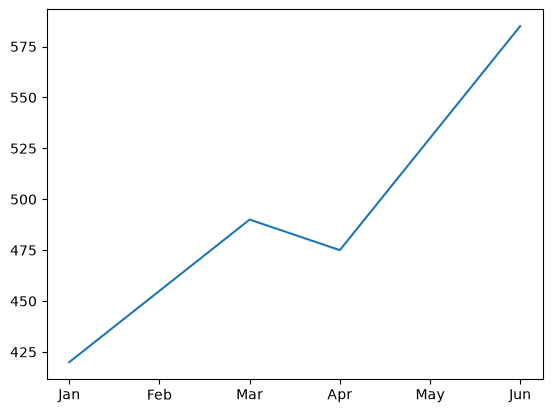

In [3]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
revenue = [420, 455, 490, 475, 530, 585]

plt.plot(months, revenue)
plt.show()

Three lines and there is a chart. This is Matplotlib's `pyplot` interface, and it is deliberately
easy: `plt.plot(x, y)` draws, and Matplotlib invents a figure and a set of axes behind your back to
draw on.

That convenience is also the source of most confusion later, so let us look at what it created.

## The mental model: Figure and Axes

Matplotlib has exactly two objects you need to hold in your head.

```text
┌──────────────────────────────── Figure ─────────────────────────────────┐
│  the whole image — the canvas, the thing you save to a file             │
│                                                                         │
│   ┌───────────────── Axes ──────────────┐  ┌──────── Axes ───────────┐  │
│   │  one plot: its own x-axis, y-axis,  │  │  a second plot, with    │  │
│   │  title, legend and data             │  │  its own everything     │  │
│   │                                     │  │                         │  │
│   │      ╱╲    ╱                        │  │    ▄  ▄▄  ▄             │  │
│   │     ╱  ╲  ╱                         │  │   ▄█▄ ██ ▄█▄            │  │
│   └─────────────────────────────────────┘  └─────────────────────────┘  │
└─────────────────────────────────────────────────────────────────────────┘
```

- A **Figure** is the whole picture. It has a size in inches, a resolution, and it is what gets
  written to a PNG. One figure can hold many plots.
- An **Axes** is one individual plot — the box with data in it, plus its axis lines, ticks, labels,
  title and legend. Confusingly, the object representing *one plot* is called "Axes", plural.
  It is named that because it owns the x-axis and the y-axis.

The naming is unfortunate and you will just have to absorb it:

| Word | What it means |
| --- | --- |
| Figure | the whole image |
| Axes | **one plot** inside the figure |
| Axis | a single x or y axis belonging to an Axes |

Almost every "why is my plot doing that" question comes down to acting on the wrong one of these.

figure: Figure
axes  : Axes
figure size (inches): [6.4 4.8]


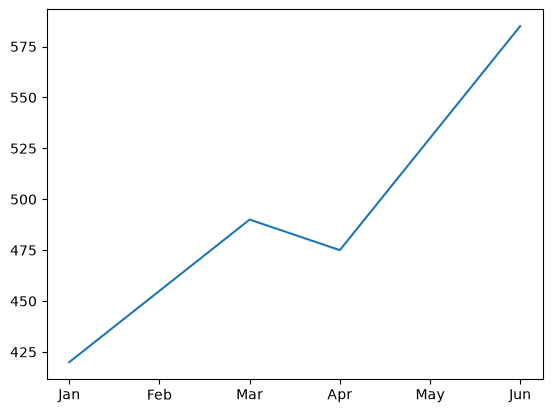

In [4]:
fig, ax = plt.subplots()

ax.plot(months, revenue)

print("figure:", type(fig).__name__)
print("axes  :", type(ax).__name__)
print("figure size (inches):", fig.get_size_inches())
plt.show()

`plt.subplots()` creates a figure and one Axes inside it, and returns both. That line is the
standard way to start a plot, and it is worth writing out what it does:

```python
fig, ax = plt.subplots()
 ↑    ↑        ↑
 the  the      creates both and returns them as a tuple
 whole one
 image plot
```

It is tuple unpacking, the same as `a, b = (1, 2)`. From then on, `ax.plot(...)` draws on that
specific plot, and `fig.savefig(...)` saves the whole image.

## The two APIs

Matplotlib gives you two ways to do everything, and this confuses every beginner reading
Stack Overflow answers, because both appear constantly.

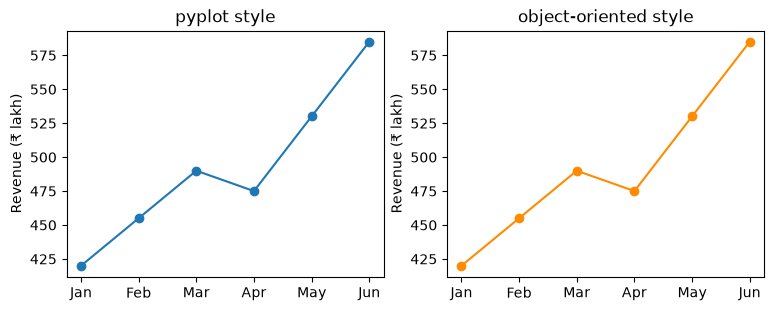

In [5]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9, 3.2))

# The pyplot ("state machine") style — plt.* acts on whichever plot is "current"
plt.sca(left)
plt.plot(months, revenue, marker="o")
plt.title("pyplot style")
plt.ylabel("Revenue (₹ lakh)")

# The object-oriented style — you name the Axes you mean
right.plot(months, revenue, marker="o", color="darkorange")
right.set_title("object-oriented style")
right.set_ylabel("Revenue (₹ lakh)")

plt.show()

Both drew the same chart. The difference is how they decide *where* to draw.

**pyplot style** keeps a hidden notion of the "current axes". `plt.title("x")` means "set the title
of whatever is current". It is shorter, and it works well when there is exactly one plot.

**Object-oriented style** requires you to name the target: `right.set_title("x")`. More typing, and
unambiguous.

Notice the method names differ: `plt.title(...)` becomes `ax.set_title(...)`, `plt.xlabel(...)`
becomes `ax.set_xlabel(...)`. The `set_` prefix is the pattern, and it applies to most of them.

### Which should you use?

The honest answer, which differs from what you will often be told:

**For a quick one-plot look at some data, `plt.plot()` is completely fine.** You are exploring, the
chart will be discarded in a minute, and three lines beats six. Anyone who tells you this is
unprofessional is optimising the wrong thing.

**For anything with more than one plot, or any figure you intend to keep, use the
object-oriented style.** Not because it is more virtuous, but because:

- With several subplots, "the current axes" becomes a thing you have to track in your head, and
  `plt.title()` will eventually set the title of the wrong one.
- A function that takes `ax` as a parameter can draw into any figure, which makes plots reusable.
- When you come back in six months, `ax.set_xlabel(...)` says which plot it affects and
  `plt.xlabel(...)` does not.

This notebook uses `plt.*` for the first few single-plot examples, then switches to the
object-oriented style and stays there.

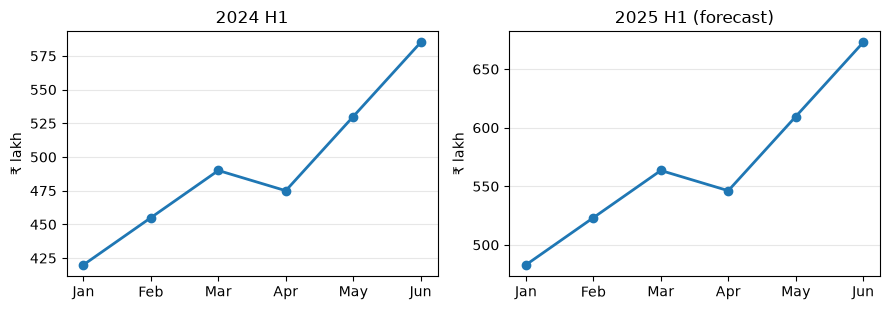

In [6]:
def revenue_panel(ax, months, values, title):
    """Draw a revenue line onto a caller-supplied Axes."""
    ax.plot(months, values, marker="o", linewidth=2)
    ax.set_title(title)
    ax.set_ylabel("₹ lakh")
    ax.grid(axis="y", alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

revenue_panel(axes[0], months, revenue, "2024 H1")
revenue_panel(axes[1], months, [x * 1.15 for x in revenue], "2025 H1 (forecast)")

fig.tight_layout()
plt.show()

That is the practical payoff of the object-oriented style: one function, reused for both panels.
With `plt.*` calls inside, the function would have drawn on whatever happened to be current, and
getting it to target a specific subplot would mean adding `plt.sca()` calls and hoping.

## The core chart types

Four charts cover most of what you need. The decision of which to use is more important than any
amount of styling, so each section starts with what the chart is *for*.

### Line plot — a value changing along a continuous axis

Use it when the x-axis has a natural order and the space between points means something: time,
distance, temperature. The line implies "and it passed through the values in between", which is why
a line chart of unordered categories is misleading.

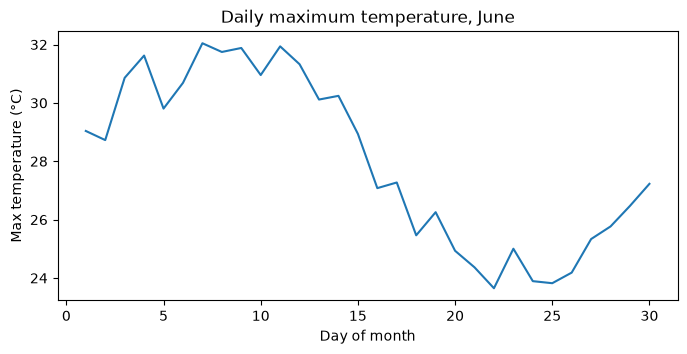

In [7]:
days = np.arange(1, 31)
rng = np.random.default_rng(42)
temperature = 28 + 4 * np.sin(days / 5) + rng.normal(0, 0.8, 30)

fig, ax = plt.subplots(figsize=(8, 3.5))

ax.plot(days, temperature)
ax.set_xlabel("Day of month")
ax.set_ylabel("Max temperature (°C)")
ax.set_title("Daily maximum temperature, June")

plt.show()

Several lines on one Axes is the natural way to compare series — just call `plot` more than once:

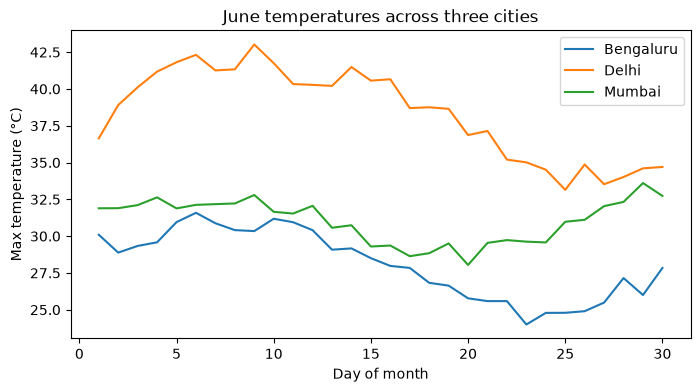

In [8]:
bengaluru = 28 + 3 * np.sin(days / 5) + rng.normal(0, 0.7, 30)
delhi = 38 + 4 * np.sin(days / 6) + rng.normal(0, 1.2, 30)
mumbai = 31 + 2 * np.sin(days / 4) + rng.normal(0, 0.6, 30)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(days, bengaluru, label="Bengaluru")
ax.plot(days, delhi, label="Delhi")
ax.plot(days, mumbai, label="Mumbai")

ax.set_xlabel("Day of month")
ax.set_ylabel("Max temperature (°C)")
ax.set_title("June temperatures across three cities")
ax.legend()

plt.show()

Each `plot` call adds to the same Axes rather than replacing what is there, and Matplotlib cycles
through its default colours automatically.

`label=` on each line plus one `ax.legend()` call builds the key. Forgetting `legend()` is the most
common omission in multi-series plots: the labels exist but nothing displays them.

### Scatter plot — the relationship between two variables

Use it when both axes are measurements and you want to see whether they move together. No line,
because there is no path from one point to the next.

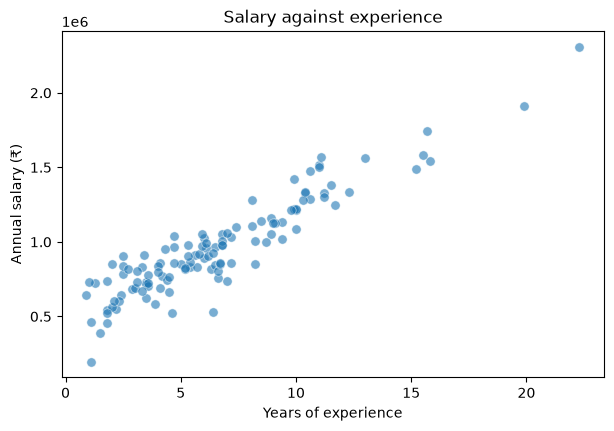

In [9]:
rng = np.random.default_rng(7)
experience = rng.gamma(2.5, 3, 120).round(1)
salary = (450_000 + experience * 78_000 + rng.normal(0, 130_000, 120)).round(-3)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.scatter(experience, salary, alpha=0.6, s=45, edgecolor="white", linewidth=0.5)

ax.set_xlabel("Years of experience")
ax.set_ylabel("Annual salary (₹)")
ax.set_title("Salary against experience")

plt.show()

Three arguments doing real work here:

- **`alpha=0.6`** makes the points slightly transparent, so overlapping points look darker. With
  120 points and no transparency, a dense cluster becomes one solid blob and you lose the
  information about where the data is concentrated.
- **`s=45`** sets the marker area. The default is small; on a figure this size, slightly larger
  points read better.
- **`edgecolor="white"`** puts a thin outline on each marker, which separates neighbouring points
  visually. A small touch that makes dense scatters much more legible.

A scatter can carry two more variables through colour and size:

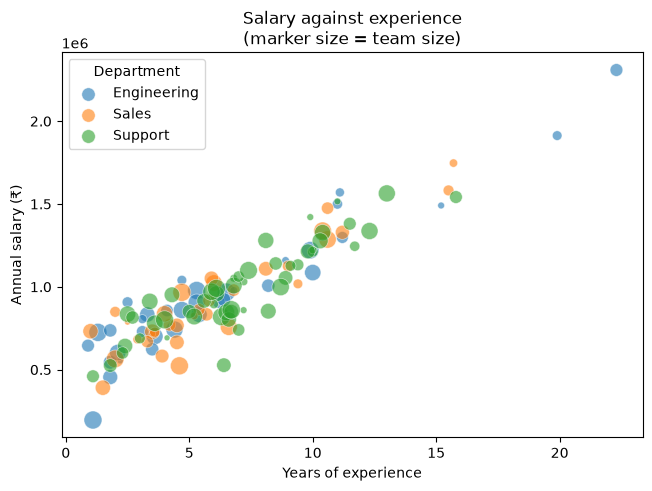

In [10]:
department_code = rng.integers(0, 3, 120)
team_size = rng.integers(3, 30, 120)
dept_names = ["Engineering", "Sales", "Support"]

fig, ax = plt.subplots(figsize=(7.5, 5))

for code, name in enumerate(dept_names):
    mask = department_code == code
    ax.scatter(experience[mask], salary[mask],
               s=team_size[mask] * 6, alpha=0.6,
               label=name, edgecolor="white", linewidth=0.5)

ax.set_xlabel("Years of experience")
ax.set_ylabel("Annual salary (₹)")
ax.set_title("Salary against experience\n(marker size = team size)")
ax.legend(title="Department")

plt.show()

The loop is the important technique. Rather than passing a list of colours, we plot each group as
its own `scatter` call using a boolean mask — which means each call can have its own `label`, and
the legend builds itself correctly.

That is the general pattern for "colour by category" in plain Matplotlib: **one call per
category**. It looks repetitive and it is the thing that makes legends work.

A caution about encoding a variable in marker size: people read area poorly, so it is suitable for
a rough "bigger means more" impression and not for values anyone needs to compare precisely. Note
also that the title had to explain what size means, because there is no automatic legend for it.

### Bar chart — comparing a value across categories

Use it when the x-axis is a set of distinct categories with no order. Bars start at zero, and
because people compare bar *lengths*, that zero baseline is not optional — more on that in the
section on honest charts.

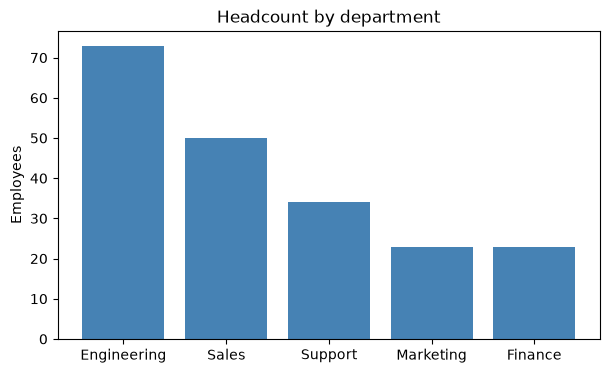

In [11]:
departments = ["Engineering", "Sales", "Support", "Marketing", "Finance"]
headcount = [73, 50, 34, 23, 23]

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(departments, headcount, color="steelblue")
ax.set_ylabel("Employees")
ax.set_title("Headcount by department")

plt.show()

With longer category names, a **horizontal** bar chart reads much better, because the labels sit
along the axis rather than being crammed underneath:

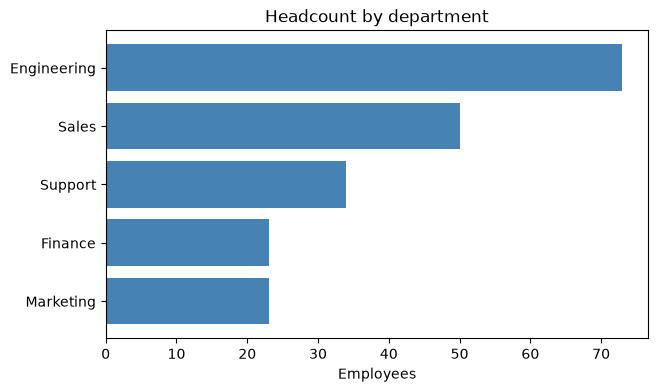

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))

order = np.argsort(headcount)
ax.barh(np.array(departments)[order], np.array(headcount)[order], color="steelblue")

ax.set_xlabel("Employees")
ax.set_title("Headcount by department")

plt.show()

Two deliberate choices there.

`barh` instead of `bar` swaps the orientation. Whenever your category labels do not fit
horizontally, reach for it before you reach for rotated text.

`np.argsort(headcount)` sorts the bars by length. This is worth doing almost every time: a sorted
bar chart lets the reader rank the categories instantly, while an unsorted one makes them compare
each pair by eye. Sort ascending for `barh` so the longest bar ends up at the top.

#### Grouped bars

Comparing two series across the same categories needs the bars side by side, and Matplotlib makes
you position them yourself.

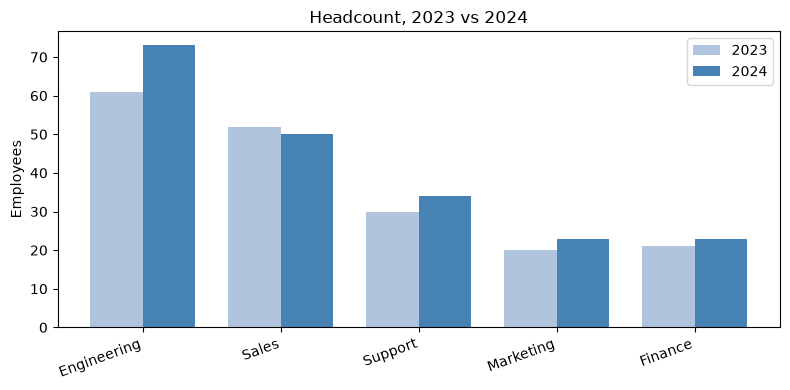

In [13]:
this_year = np.array([73, 50, 34, 23, 23])
last_year = np.array([61, 52, 30, 20, 21])

x = np.arange(len(departments))
width = 0.38

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(x - width / 2, last_year, width, label="2023", color="lightsteelblue")
ax.bar(x + width / 2, this_year, width, label="2024", color="steelblue")

ax.set_xticks(x)
ax.set_xticklabels(departments, rotation=20, ha="right")
ax.set_ylabel("Employees")
ax.set_title("Headcount, 2023 vs 2024")
ax.legend()

fig.tight_layout()
plt.show()

The positioning logic, since it is not obvious:

- `x = np.arange(5)` gives the category positions `0, 1, 2, 3, 4`.
- `width = 0.38` is each bar's width, in the same units. Two bars of 0.38 plus a small gap fit
  inside the 1.0 of space per category.
- `x - width/2` shifts the first series left of centre, `x + width/2` shifts the second right.
- `set_xticks(x)` then `set_xticklabels(departments)` puts the category names at the centres.

`ha="right"` sets horizontal alignment for the rotated labels, so they end near their tick rather
than drifting off to the side. Rotated labels without `ha="right"` look misaligned, and that one
argument fixes it.

#### Stacked bars

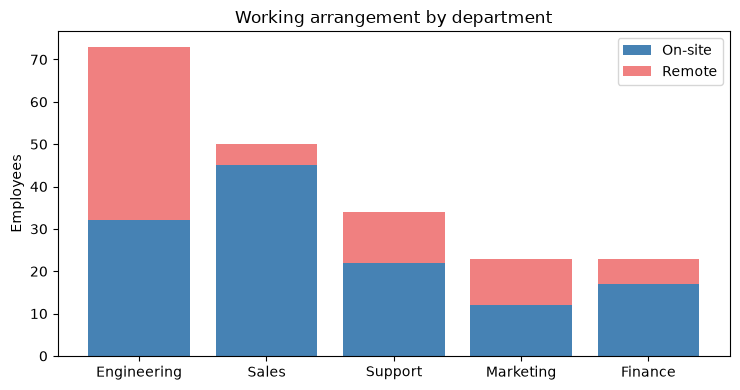

In [14]:
remote = np.array([41, 5, 12, 11, 6])
on_site = this_year - remote

fig, ax = plt.subplots(figsize=(7.5, 4))

ax.bar(departments, on_site, label="On-site", color="steelblue")
ax.bar(departments, remote, bottom=on_site, label="Remote", color="lightcoral")

ax.set_ylabel("Employees")
ax.set_title("Working arrangement by department")
ax.legend()

fig.tight_layout()
plt.show()

`bottom=on_site` is what stacks the second series: it starts each remote bar at the top of the
corresponding on-site bar.

Stacked bars are good for showing **totals** and roughly how they divide. They are poor for
comparing the individual segments, because only the bottom segment starts from a common baseline —
try comparing the remote counts across departments above and you will notice the difficulty.
If the segments are the point, use grouped bars instead.

### Histogram — the distribution of one variable

A histogram is not a bar chart. A bar chart has one bar per category; a histogram slices a
continuous variable into ranges and counts how many values land in each. Use it to answer "what
does this variable look like" — where is the bulk, is it symmetric, are there outliers.

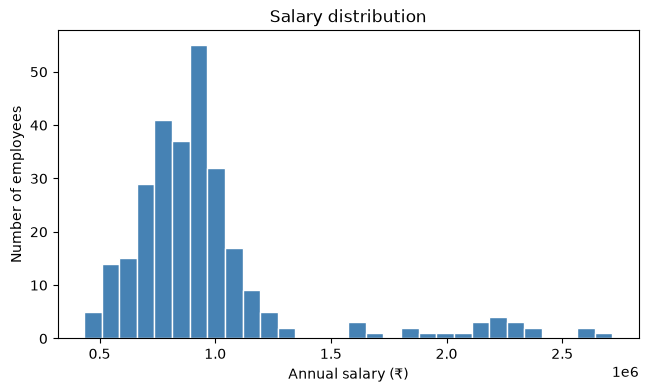

In [15]:
rng = np.random.default_rng(11)
salaries = np.concatenate([
    rng.normal(850_000, 180_000, 260),
    rng.normal(2_100_000, 400_000, 25),
])

fig, ax = plt.subplots(figsize=(7.5, 4))

ax.hist(salaries, bins=30, color="steelblue", edgecolor="white")
ax.set_xlabel("Annual salary (₹)")
ax.set_ylabel("Number of employees")
ax.set_title("Salary distribution")

plt.show()

The shape is immediately informative: most people cluster around 850,000, and there is a separate
small group above 2,000,000. A mean would sit in the empty space between the two humps and describe
nobody — which is exactly the kind of thing a histogram catches and a summary statistic hides.

#### The `bins` argument matters more than anything else

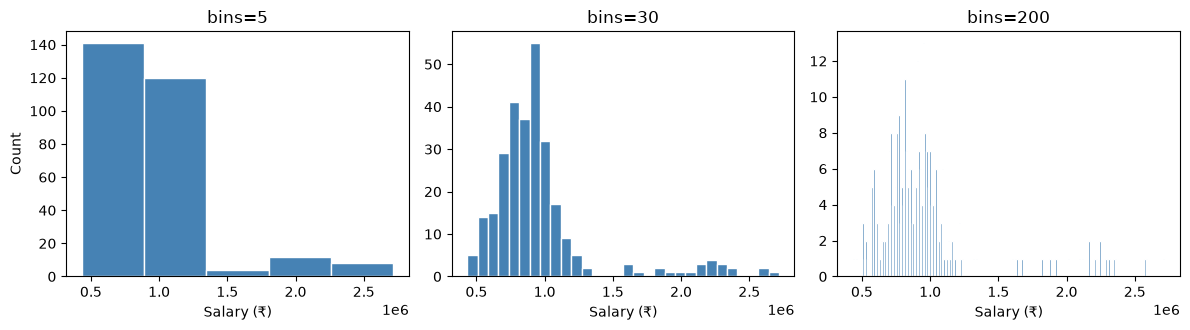

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))

for ax, n_bins in zip(axes, [5, 30, 200]):
    ax.hist(salaries, bins=n_bins, color="steelblue", edgecolor="white")
    ax.set_title(f"bins={n_bins}")
    ax.set_xlabel("Salary (₹)")

axes[0].set_ylabel("Count")
fig.tight_layout()
plt.show()

Same data, three very different impressions.

- **Too few bins** (5) smooths everything into one lump. The second group of high earners has
  disappeared entirely.
- **A sensible number** (30) shows the real structure.
- **Too many bins** (200) makes random noise look like structure; each bar holds one or two people.

There is no formula that is always right. Start with the default, try a couple of values, and pick
one that shows the shape without inventing detail. If a feature appears at one bin count and
vanishes at another, be suspicious of it.

#### Density instead of counts

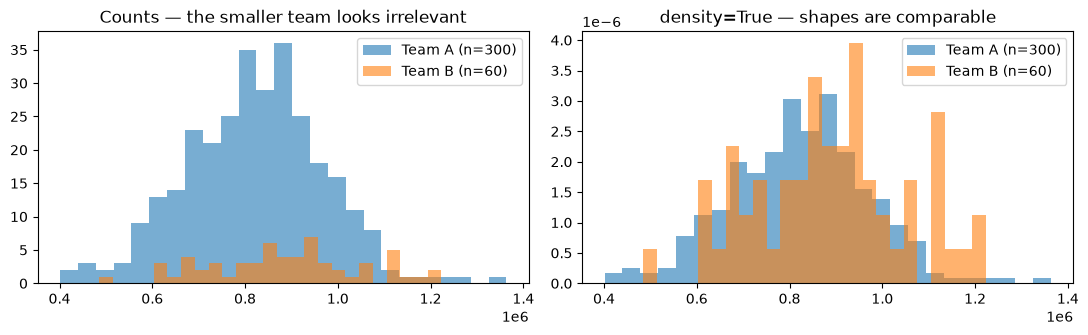

In [17]:
group_a = rng.normal(820_000, 150_000, 300)
group_b = rng.normal(880_000, 150_000, 60)

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.6))

left.hist(group_a, bins=25, alpha=0.6, label="Team A (n=300)")
left.hist(group_b, bins=25, alpha=0.6, label="Team B (n=60)")
left.set_title("Counts — the smaller team looks irrelevant")
left.legend()

right.hist(group_a, bins=25, alpha=0.6, density=True, label="Team A (n=300)")
right.hist(group_b, bins=25, alpha=0.6, density=True, label="Team B (n=60)")
right.set_title("density=True — shapes are comparable")
right.legend()

fig.tight_layout()
plt.show()

With raw counts, a group five times larger dominates and you cannot compare the distributions.
`density=True` scales each histogram so its total area is 1, which makes the *shapes* comparable at
the cost of no longer being able to read counts off the y-axis.

Use counts when the number of observations matters, density when the shape does. Note that the
sample sizes belong in the legend either way — a smooth-looking density curve from 60 observations
deserves less trust than one from 300.

### Pie charts, and when not to use them

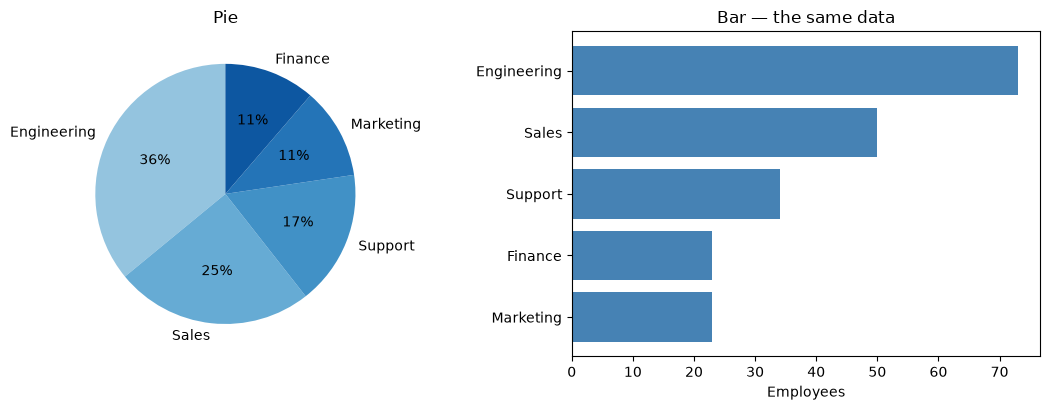

In [18]:
labels = ["Engineering", "Sales", "Support", "Marketing", "Finance"]
values = [73, 50, 34, 23, 23]

fig, (pie_ax, bar_ax) = plt.subplots(1, 2, figsize=(11, 4.2))

pie_ax.pie(values, labels=labels, autopct="%1.0f%%", startangle=90,
           colors=plt.get_cmap("Blues")(np.linspace(0.4, 0.85, len(values))))
pie_ax.set_title("Pie")

bar_order = np.argsort(values)
bar_ax.barh(np.array(labels)[bar_order], np.array(values)[bar_order], color="steelblue")
bar_ax.set_title("Bar — the same data")
bar_ax.set_xlabel("Employees")

fig.tight_layout()
plt.show()

Look at Marketing and Finance — both 23. On the bar chart they are obviously equal. On the pie you
have to read the percentages to be sure, because people judge angles poorly. That is the whole
case against pie charts: they make the reader work harder for less precision.

Where a pie is defensible:

- There are **two or three** slices, not five or ten.
- The point is "this is roughly half" rather than any comparison between slices.
- The parts genuinely sum to a meaningful whole.

Where it fails: many slices, similar slices, comparing two pies against each other, or — worst —
slices that do not add up to 100%.

`autopct="%1.0f%%"` writes the percentages on the slices, which partly compensates for the
readability problem. If you find yourself needing the numbers printed on every slice for the chart
to be readable, that is a sign the chart type is doing nothing for you.

`plt.get_cmap("Blues")(np.linspace(0.4, 0.85, 5))` picks five evenly spaced shades from the Blues
colormap — a tidy way to get a related set of colours. (In older code you may see
`plt.cm.get_cmap(...)`, which was removed in recent Matplotlib; `plt.get_cmap` is the current
spelling.)

### Choosing a chart type

| Question | Chart |
| --- | --- |
| How did this change over time? | line |
| Do these two measurements move together? | scatter |
| How does this value compare across categories? | bar (sorted; horizontal if labels are long) |
| What does this variable's distribution look like? | histogram |
| How do distributions compare across a few groups? | box plot, or overlaid histograms with `density=True` |
| How does a total split into parts? | stacked bar — or a pie, if there are two or three parts |
| Two categorical dimensions at once? | grouped bar, or a heatmap |

## Exercises — first plots

**Level 1.** Plot the monthly revenue from the start of this notebook as a bar chart with a title
and both axis labels.

**Level 2.** Using `experience` and `salary` from the scatter section, draw a scatter plot and add
a straight trend line through it. (`np.polyfit(x, y, 1)` returns the slope and intercept of the
best-fit line.)

**Level 3.** Take the `salaries` array from the histogram section, which has two distinct groups in
it. Produce one figure that makes the two-group structure as obvious as possible, and write two or
three sentences explaining your choices — chart type, bin count, and anything else you changed.

## Plot anatomy

Everything visible on a chart is an object you can control. Here is the vocabulary, drawn on a
plot so the names attach to things you can see.

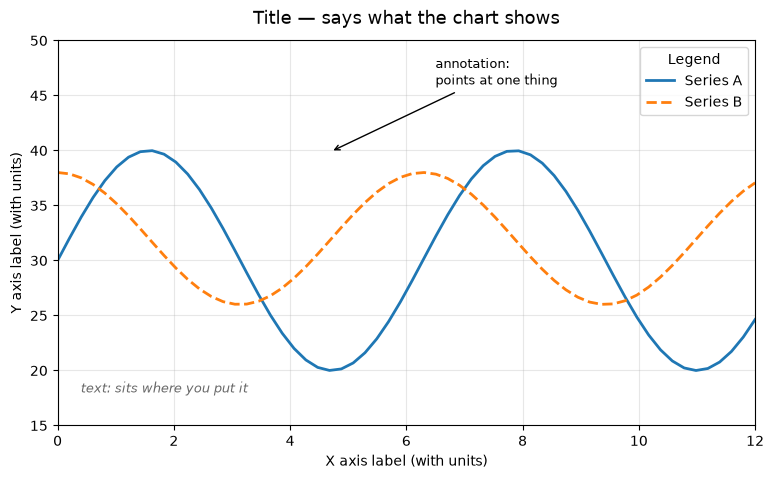

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.linspace(0, 12, 60)
ax.plot(x, np.sin(x) * 10 + 30, label="Series A", linewidth=2)
ax.plot(x, np.cos(x) * 6 + 32, label="Series B", linewidth=2, linestyle="--")

ax.set_title("Title — says what the chart shows", fontsize=13, pad=12)
ax.set_xlabel("X axis label (with units)")
ax.set_ylabel("Y axis label (with units)")
ax.legend(title="Legend", loc="upper right")
ax.grid(alpha=0.3)
ax.set_xlim(0, 12)
ax.set_ylim(15, 50)

ax.annotate("annotation:\npoints at one thing",
            xy=(4.7, 39.9), xytext=(6.5, 46),
            arrowprops=dict(arrowstyle="->", color="black", lw=1),
            fontsize=9)

ax.text(0.4, 18, "text: sits where you put it", fontsize=9, style="italic", color="dimgray")

plt.show()

The parts, and what each is for:

| Part | Set with | Purpose |
| --- | --- | --- |
| Title | `ax.set_title()` | What this chart shows. One line, specific. |
| Axis labels | `ax.set_xlabel()` / `set_ylabel()` | What the numbers mean, **including units** |
| Ticks | `ax.set_xticks()` / `set_yticks()` | Which values are marked |
| Tick labels | `ax.set_xticklabels()` | What the marks say |
| Limits | `ax.set_xlim()` / `set_ylim()` | The visible range |
| Legend | `ax.legend()` | Which line is which — needed whenever there is more than one |
| Grid | `ax.grid()` | Helps read values off the chart; should be faint |
| Annotation | `ax.annotate()` | Points at a specific data point |
| Text | `ax.text()` | Free-floating note at given coordinates |
| Spines | `ax.spines[...]` | The box lines around the plot |

The two that are not optional are **axis labels** and, when there are multiple series, a
**legend**. A chart without them is unreadable by anyone but its author, including its author next
month.

### Titles and labels

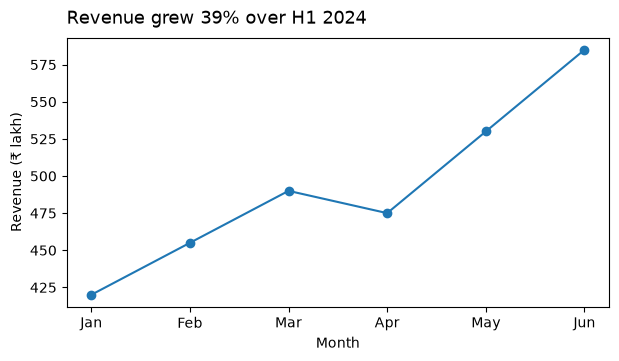

In [20]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(months, revenue, marker="o")

ax.set_title("Revenue grew 39% over H1 2024", fontsize=13, loc="left", pad=10)
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (₹ lakh)")

plt.show()

Note the title: "Revenue grew 39% over H1 2024", not "Revenue by month". The axis labels already
say the chart shows revenue by month; the title's job is to say what the reader should take from
it. That is a small habit with a large effect on how useful your charts are.

`loc="left"` left-aligns the title, which reads more naturally for a headline-style title, and
`pad=10` adds a little space between title and plot.

### Axis limits

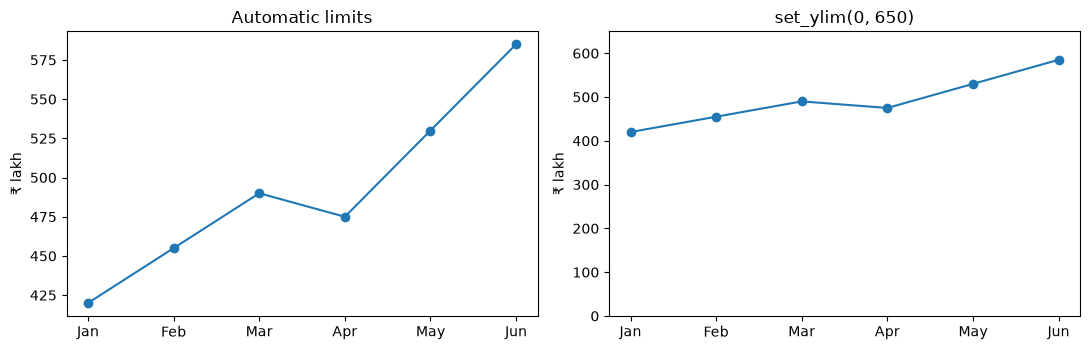

In [21]:
fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.6))

a.plot(months, revenue, marker="o")
a.set_title("Automatic limits")
a.set_ylabel("₹ lakh")

b.plot(months, revenue, marker="o")
b.set_ylim(0, 650)
b.set_title("set_ylim(0, 650)")
b.set_ylabel("₹ lakh")

fig.tight_layout()
plt.show()

Matplotlib chooses limits to fit the data with a little padding, which maximises the visible
variation. That is usually what you want when exploring, and it is the thing to be careful about
when publishing: the left chart makes the growth look dramatic because the axis starts around 410.

For a **line** chart, a non-zero axis is often legitimate — nobody thinks a temperature line
implies zero degrees. For **bars**, it is not, because bar length is the encoding. The section on
honest charts returns to this.

### Ticks

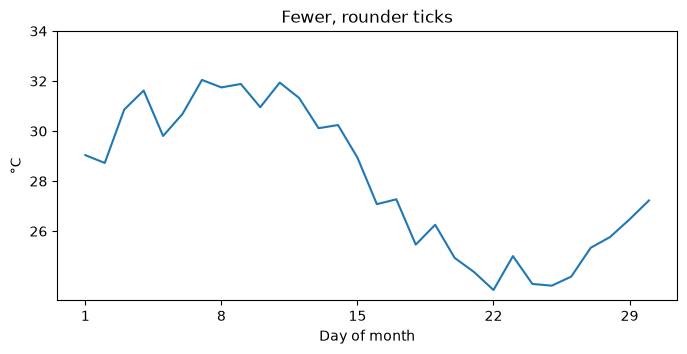

In [22]:
fig, ax = plt.subplots(figsize=(8, 3.5))

ax.plot(days, temperature, linewidth=1.5)

ax.set_xticks([1, 8, 15, 22, 29])
ax.set_yticks([26, 28, 30, 32, 34])
ax.set_xlabel("Day of month")
ax.set_ylabel("°C")
ax.set_title("Fewer, rounder ticks")

plt.show()

Matplotlib's automatic ticks are generally good. Override them when:

- there are too many and the labels collide,
- you want round numbers rather than whatever the data range produced,
- the values are categories and every one should be labelled.

`ax.tick_params` handles the appearance rather than the positions:

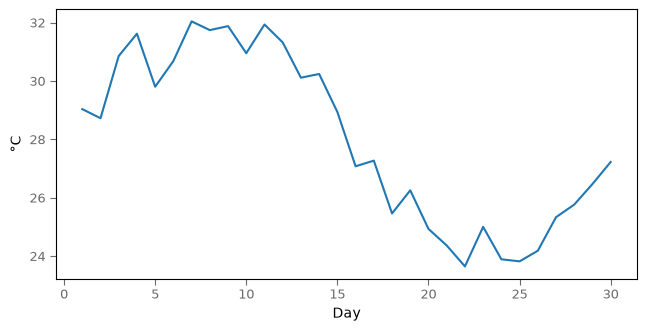

In [23]:
fig, ax = plt.subplots(figsize=(7.5, 3.5))

ax.plot(days, temperature)
ax.tick_params(axis="both", labelsize=9, length=4, colors="dimgray")
ax.set_xlabel("Day", fontsize=10)
ax.set_ylabel("°C", fontsize=10)

plt.show()

Formatting large numbers on an axis is a common need, and a formatter function is the clean way:

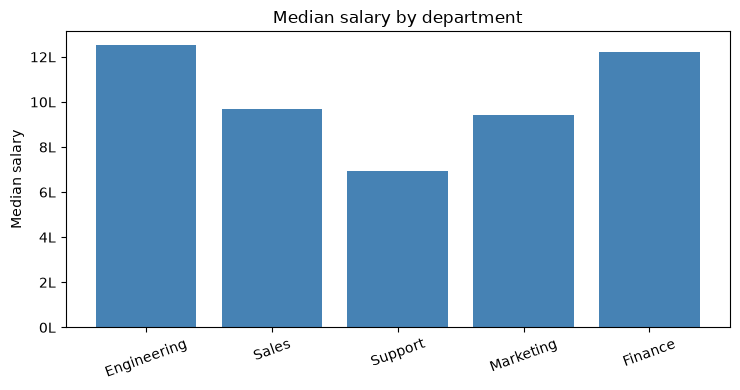

In [24]:
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(7.5, 4))

ax.bar(departments, [1_251_000, 970_000, 692_000, 943_000, 1_221_000], color="steelblue")

ax.yaxis.set_major_formatter(FuncFormatter(lambda value, pos: f"{value / 100_000:.0f}L"))
ax.set_ylabel("Median salary")
ax.set_title("Median salary by department")
ax.tick_params(axis="x", rotation=20)

fig.tight_layout()
plt.show()

`FuncFormatter` takes a function of `(value, position)` and returns the string to display. Here
every y tick is divided by 100,000 and suffixed with "L" for lakh. The alternative — dividing the
data itself before plotting — works too, but then the axis label has to carry the unit and readers
have to do the conversion mentally.

The `pos` argument is required by the interface even when you ignore it, which is why the lambda
takes two parameters and uses one.

### Legends

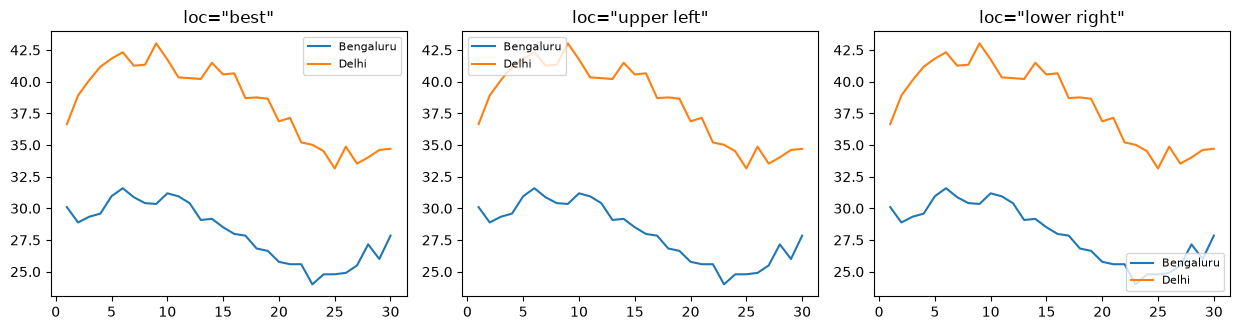

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))

for ax, loc in zip(axes, ["best", "upper left", "lower right"]):
    ax.plot(days, bengaluru, label="Bengaluru")
    ax.plot(days, delhi, label="Delhi")
    ax.legend(loc=loc, fontsize=8)
    ax.set_title(f'loc="{loc}"')

fig.tight_layout()
plt.show()

`loc="best"` lets Matplotlib find the emptiest corner, which is the right default. Specify a
position when "best" picks somewhere that covers data, or when you want several figures to be
consistent.

For a legend that will not fit inside the plot, put it outside:

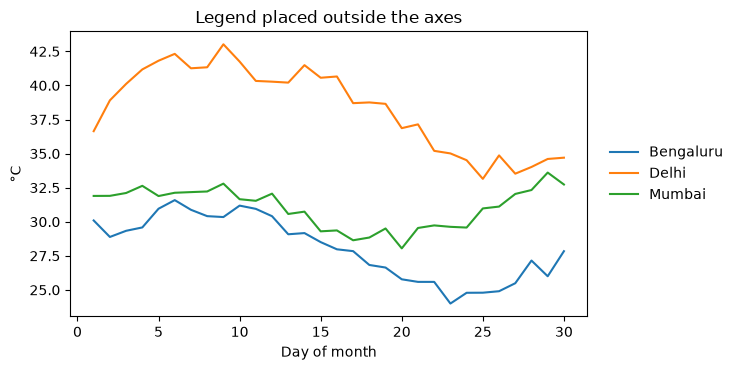

In [26]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))

for label, series in [("Bengaluru", bengaluru), ("Delhi", delhi), ("Mumbai", mumbai)]:
    ax.plot(days, series, label=label)

ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
ax.set_xlabel("Day of month")
ax.set_ylabel("°C")
ax.set_title("Legend placed outside the axes")

fig.tight_layout()
plt.show()

`bbox_to_anchor=(1.02, 0.5)` positions the legend in **axes coordinates**, where `(0, 0)` is the
bottom-left of the plot and `(1, 1)` the top-right. So `1.02` is just outside the right edge and
`0.5` is halfway up. `fig.tight_layout()` then makes room for it instead of letting it fall off
the figure.

Another option for labelled lines is to skip the legend and label each line directly at its end,
which removes the back-and-forth of matching colours to names:

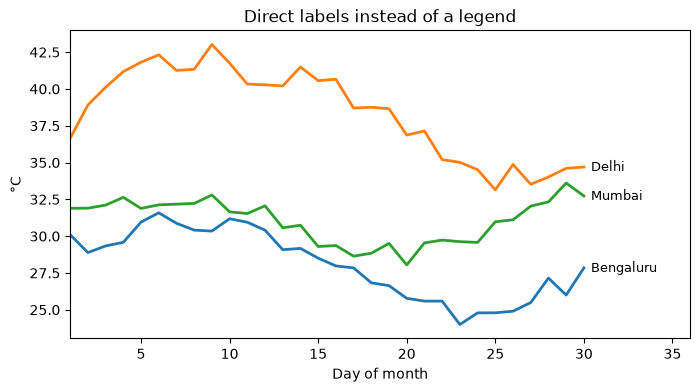

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))

for label, series in [("Bengaluru", bengaluru), ("Delhi", delhi), ("Mumbai", mumbai)]:
    ax.plot(days, series, linewidth=2)
    ax.text(days[-1] + 0.4, series[-1], label, va="center", fontsize=9)

ax.set_xlim(1, 36)
ax.set_xlabel("Day of month")
ax.set_ylabel("°C")
ax.set_title("Direct labels instead of a legend")

plt.show()

`ax.set_xlim(1, 36)` extends the x-axis past the data to leave room for the text. This takes more
care than `ax.legend()` and reads better when it works — worth the effort for a chart people will
actually look at, and not worth it for exploration.

### Grids

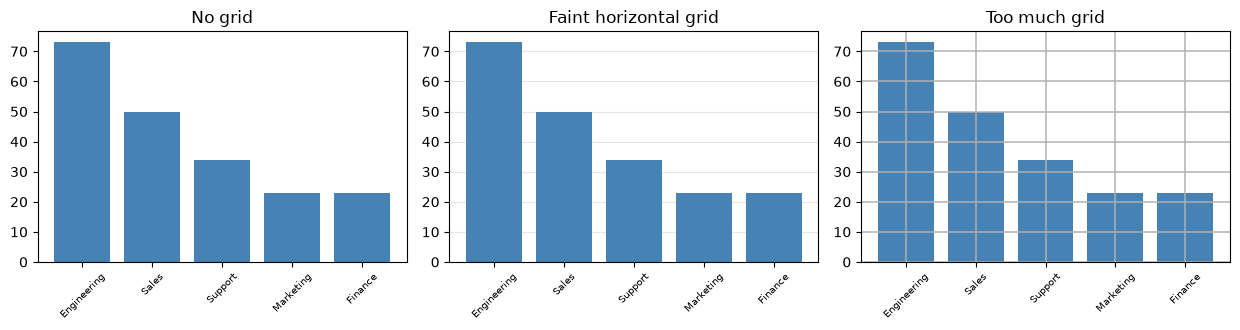

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))

axes[0].bar(departments, headcount, color="steelblue")
axes[0].set_title("No grid")

axes[1].bar(departments, headcount, color="steelblue")
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_axisbelow(True)
axes[1].set_title("Faint horizontal grid")

axes[2].bar(departments, headcount, color="steelblue")
axes[2].grid(alpha=0.9, linewidth=1.2)
axes[2].set_title("Too much grid")

for ax in axes:
    ax.tick_params(axis="x", rotation=45, labelsize=7)

fig.tight_layout()
plt.show()

The middle one is the version to copy: `axis="y"` only (vertical grid lines add nothing to a bar
chart), `alpha=0.3` so the grid supports the data rather than competing with it, and
`set_axisbelow(True)` so the grid is drawn *behind* the bars. Without that last line the grid
lines run across the bars, which looks like a mistake because it is one.

### Annotations

An annotation is how you make one point in the data explicit.

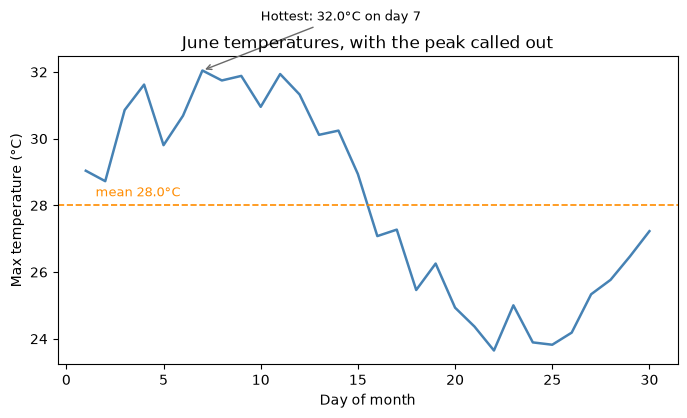

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(days, temperature, linewidth=1.8, color="steelblue")

peak = temperature.argmax()
ax.annotate(f"Hottest: {temperature[peak]:.1f}°C on day {days[peak]}",
            xy=(days[peak], temperature[peak]),
            xytext=(days[peak] + 3, temperature[peak] + 1.5),
            arrowprops=dict(arrowstyle="->", color="dimgray"),
            fontsize=9)

ax.axhline(temperature.mean(), color="darkorange", linestyle="--", linewidth=1.2)
ax.text(1.5, temperature.mean() + 0.25, f"mean {temperature.mean():.1f}°C",
        color="darkorange", fontsize=9)

ax.set_xlabel("Day of month")
ax.set_ylabel("Max temperature (°C)")
ax.set_title("June temperatures, with the peak called out")

plt.show()

`ax.annotate` takes two coordinate pairs: `xy` is the point being pointed at, `xytext` is where the
text goes. `arrowprops` draws the connector; omit it and you get text with no arrow.

`ax.axhline(y)` draws a horizontal line across the whole plot — perfect for a mean, a target or a
threshold. `ax.axvline(x)` is the vertical equivalent, useful for marking an event in a time series.
`ax.axhspan(low, high)` shades a band, for a tolerance range.

Note that the annotation text is computed from the data (`temperature[peak]`) rather than typed in.
Hard-coding "Hottest: 34.2°C" means the label goes stale the moment the data changes, and stale
labels are worse than no labels.

### Colours, line styles and markers

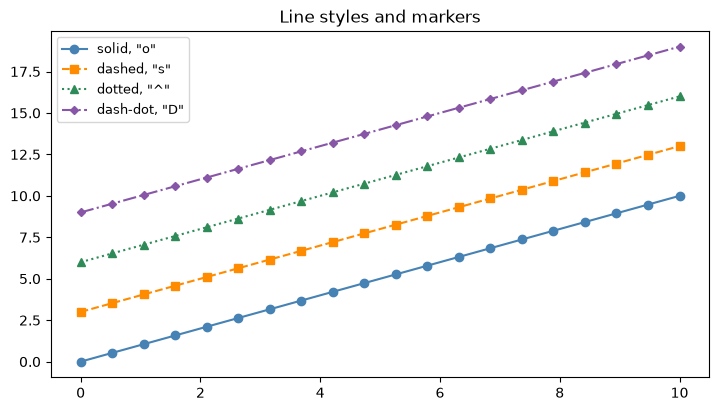

In [30]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))

x = np.linspace(0, 10, 20)

ax.plot(x, x, color="steelblue", linestyle="-", marker="o", label='solid, "o"')
ax.plot(x, x + 3, color="darkorange", linestyle="--", marker="s", label='dashed, "s"')
ax.plot(x, x + 6, color="seagreen", linestyle=":", marker="^", label='dotted, "^"')
ax.plot(x, x + 9, color="#8856a7", linestyle="-.", marker="D", markersize=4,
        label='dash-dot, "D"')

ax.legend(fontsize=9)
ax.set_title("Line styles and markers")

plt.show()

Colours can be given as:

- a **name**: `"steelblue"`, `"darkorange"`, `"crimson"` — the full CSS colour list works
- a **hex code**: `"#8856a7"`
- a **grey level** as a string: `"0.4"`
- a tuple of RGB values in 0–1: `(0.2, 0.4, 0.6)`

Line styles are `"-"` (solid), `"--"` (dashed), `":"` (dotted), `"-."` (dash-dot). Common markers
are `"o"` circle, `"s"` square, `"^"` triangle, `"D"` diamond, `"x"` cross, `"."` small dot.

Two practical notes on colour:

**Use line style as well as colour** when a chart may be printed in black and white, or read by
someone with colour vision deficiency. Two lines distinguished only by red versus green are
invisible to about 1 in 12 men.

**Do not set colours by hand without a reason.** Matplotlib's default cycle is chosen to be
distinguishable; picking your own usually makes things worse unless you are matching a brand or
encoding meaning (red for losses, grey for context).

In [31]:
print("the default colour cycle:")
print(plt.rcParams["axes.prop_cycle"].by_key()["color"])

the default colour cycle:
[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765), (1.0, 0.4980392156862745, 0.054901960784313725), (0.17254901960784313, 0.6274509803921569, 0.17254901960784313), (0.8392156862745098, 0.15294117647058825, 0.1568627450980392), (0.5803921568627451, 0.403921568627451, 0.7411764705882353), (0.5490196078431373, 0.33725490196078434, 0.29411764705882354), (0.8901960784313725, 0.4666666666666667, 0.7607843137254902), (0.4980392156862745, 0.4980392156862745, 0.4980392156862745), (0.7372549019607844, 0.7411764705882353, 0.13333333333333333), (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]


### Styles

In [32]:
print("some available styles:", [s for s in plt.style.available if not s.startswith("_")][:12])

some available styles: ['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'petroff6', 'petroff8', 'seaborn-v0_8']


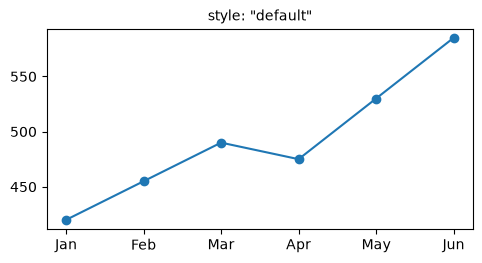

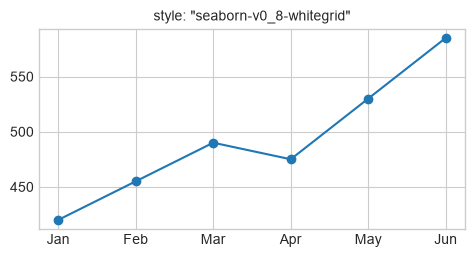

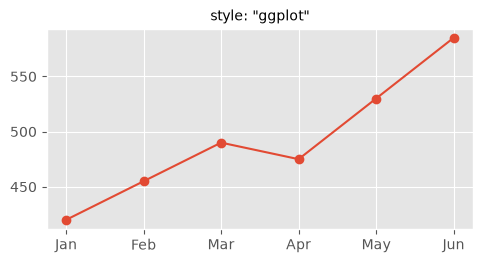

In [33]:
for style in ["default", "seaborn-v0_8-whitegrid", "ggplot"]:
    with plt.style.context(style):
        fig, ax = plt.subplots(figsize=(5.5, 2.6))
        ax.plot(months, revenue, marker="o")
        ax.set_title(f'style: "{style}"', fontsize=10)
        plt.show()

`plt.style.use("ggplot")` changes the defaults for the rest of the session.
`with plt.style.context(style):` applies it only inside the block, which is what we did here so
that the rest of the notebook keeps the standard look.

Using a style is the cheapest way to make a whole set of charts look consistent and deliberate. Pick
one, use it for the whole document, and spend your effort on the content instead.

## Multiple plots in one figure

axes is a ndarray with shape (2, 2)


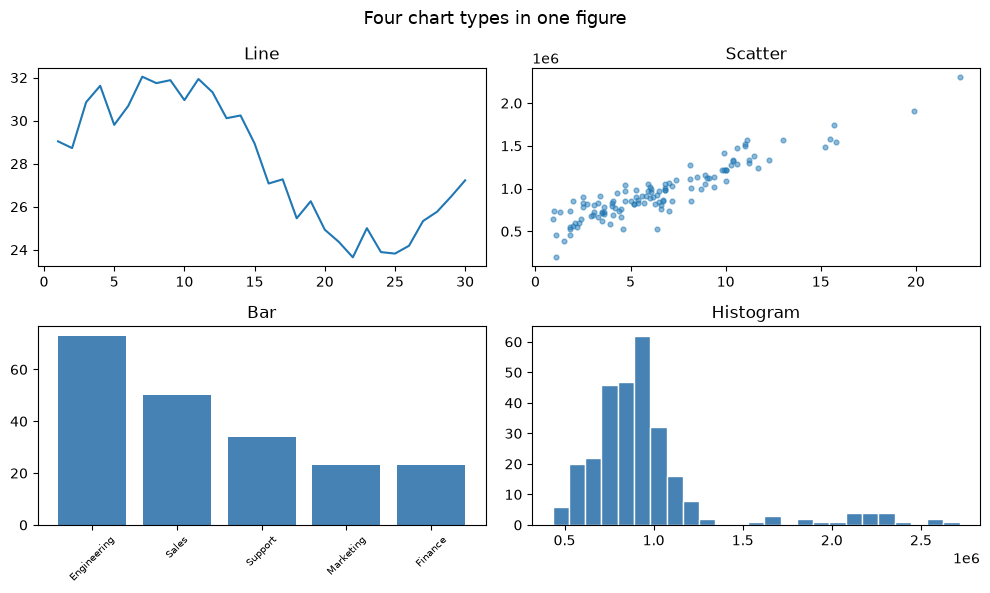

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

print("axes is a", type(axes).__name__, "with shape", axes.shape)

axes[0, 0].plot(days, temperature)
axes[0, 0].set_title("Line")

axes[0, 1].scatter(experience, salary, s=12, alpha=0.5)
axes[0, 1].set_title("Scatter")

axes[1, 0].bar(departments, headcount, color="steelblue")
axes[1, 0].tick_params(axis="x", rotation=45, labelsize=7)
axes[1, 0].set_title("Bar")

axes[1, 1].hist(salaries, bins=25, color="steelblue", edgecolor="white")
axes[1, 1].set_title("Histogram")

fig.suptitle("Four chart types in one figure", fontsize=13)
fig.tight_layout()
plt.show()

`plt.subplots(2, 2)` returns the figure and a **NumPy array** of Axes with shape `(2, 2)`, which is
why you index it as `axes[0, 1]`. If that looks familiar, it is precisely the 2D indexing from the
NumPy notebook.

`fig.suptitle` is the title for the whole figure, distinct from each Axes' own title.

`fig.tight_layout()` recalculates the spacing so nothing overlaps. Without it, subplot titles and
axis labels collide with their neighbours:

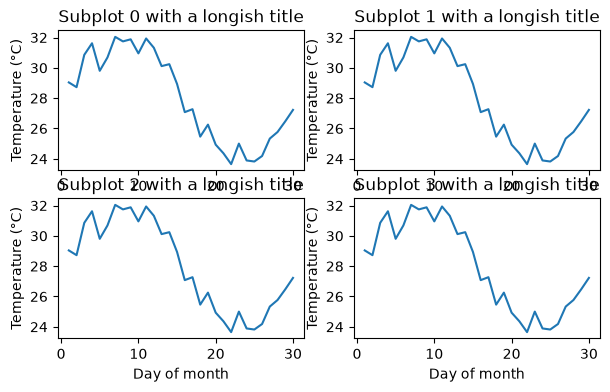

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(7, 4))

for i, ax in enumerate(axes.flat):
    ax.plot(days, temperature)
    ax.set_title(f"Subplot {i} with a longish title")
    ax.set_xlabel("Day of month")
    ax.set_ylabel("Temperature (°C)")

plt.show()

That is what forgetting `tight_layout()` looks like. And with it:

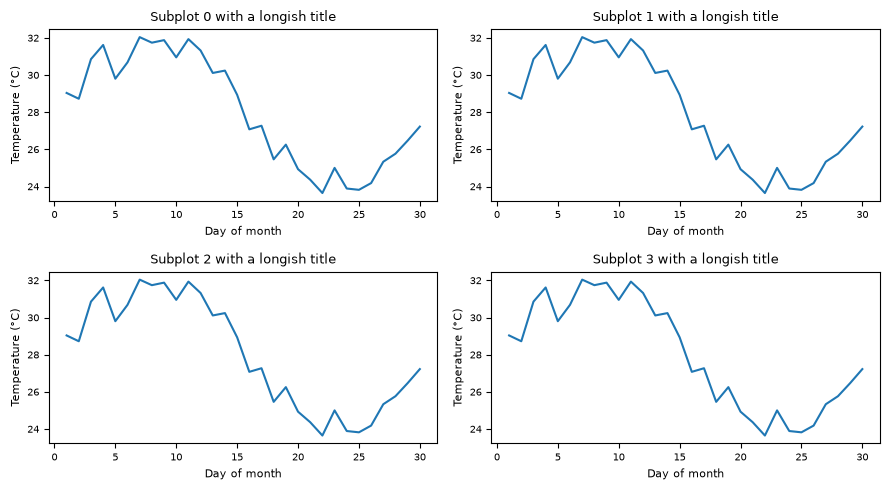

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(9, 5))

for i, ax in enumerate(axes.flat):
    ax.plot(days, temperature)
    ax.set_title(f"Subplot {i} with a longish title", fontsize=9)
    ax.set_xlabel("Day of month", fontsize=8)
    ax.set_ylabel("Temperature (°C)", fontsize=8)
    ax.tick_params(labelsize=7)

fig.tight_layout()
plt.show()

`axes.flat` iterates over all four Axes regardless of the grid shape, which saves a nested loop.
It is the standard way to apply the same setup to every subplot.

`layout="constrained"` is a newer alternative to `tight_layout()`, passed when you create the
figure, and it generally handles legends and colorbars better:

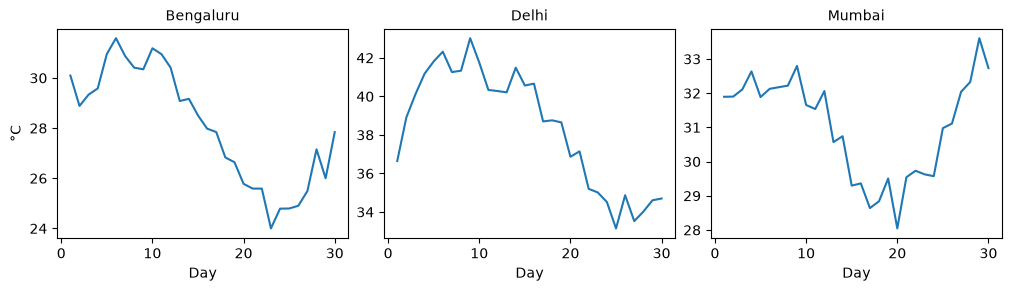

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(10, 2.8), layout="constrained")

for ax, city, series in zip(axes, ["Bengaluru", "Delhi", "Mumbai"],
                            [bengaluru, delhi, mumbai]):
    ax.plot(days, series, linewidth=1.5)
    ax.set_title(city, fontsize=10)
    ax.set_xlabel("Day")

axes[0].set_ylabel("°C")
plt.show()

### Shared axes

Those three panels have different y-ranges, which makes the cities look more similar than they are.
Delhi is around 38°C and Bengaluru around 28°C, but each panel scaled to its own data.

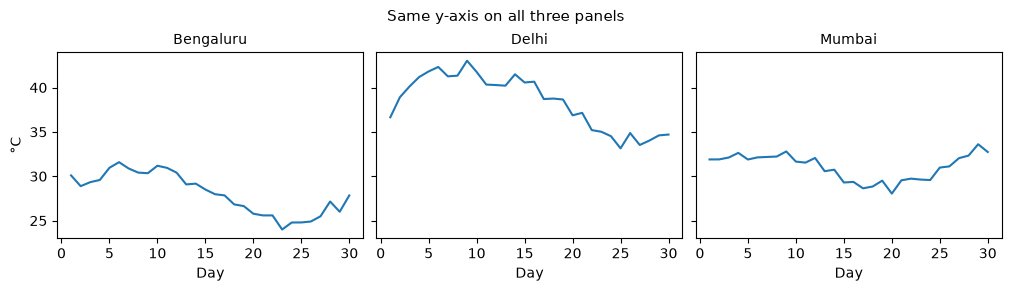

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(10, 2.8), sharey=True, layout="constrained")

for ax, city, series in zip(axes, ["Bengaluru", "Delhi", "Mumbai"],
                            [bengaluru, delhi, mumbai]):
    ax.plot(days, series, linewidth=1.5)
    ax.set_title(city, fontsize=10)
    ax.set_xlabel("Day")

axes[0].set_ylabel("°C")
fig.suptitle("Same y-axis on all three panels", fontsize=11)
plt.show()

`sharey=True` puts every panel on one scale, and now the comparison is honest — Delhi is visibly
hotter. It also removes the repeated tick labels from the inner panels, which reduces clutter.

**Use `sharey=True` whenever the panels show the same quantity.** Panels that look comparable but
are not is one of the most common ways a chart misleads, and it happens by default.

`sharex=True` does the same for the x-axis, and is useful for stacked time-series panels:

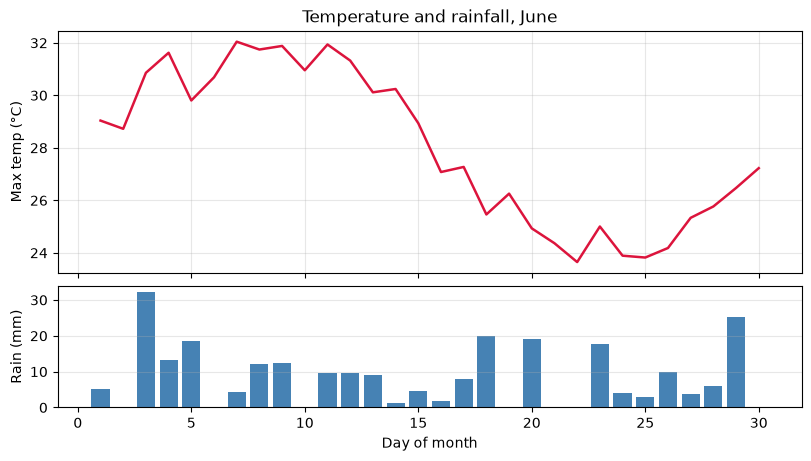

In [39]:
fig, (top, bottom) = plt.subplots(2, 1, figsize=(8, 4.5), sharex=True,
                                  height_ratios=[2, 1], layout="constrained")

top.plot(days, temperature, color="crimson", linewidth=1.8)
top.set_ylabel("Max temp (°C)")
top.grid(alpha=0.3)

rainfall = np.clip(rng.gamma(1.2, 6, 30) - 2, 0, None)
bottom.bar(days, rainfall, color="steelblue")
bottom.set_ylabel("Rain (mm)")
bottom.set_xlabel("Day of month")
bottom.grid(axis="y", alpha=0.3)

top.set_title("Temperature and rainfall, June")
plt.show()

Two quantities with different units sharing a time axis. `height_ratios=[2, 1]` makes the top panel
twice as tall, giving the primary series more room.

This is almost always better than the alternative — two y-axes on one plot — which invites the
reader to see a relationship between two arbitrarily scaled lines. If you do need a secondary axis,
`ax.twinx()` creates one, and you should label both axes in the colours of their series so it is
clear which is which.

### Uneven layouts

For a dashboard where panels have different sizes, `subplot_mosaic` is by far the easiest tool:

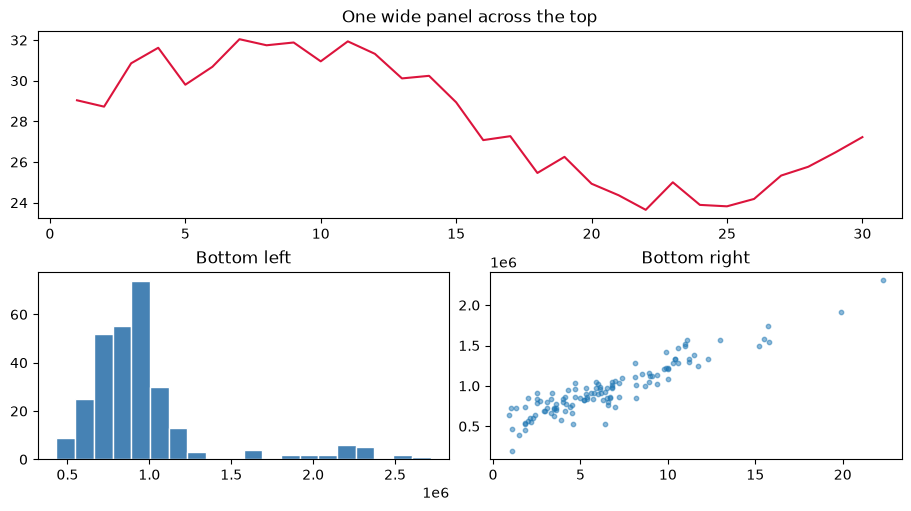

In [40]:
fig, axd = plt.subplot_mosaic(
    [["wide", "wide"],
     ["left", "right"]],
    figsize=(9, 5), layout="constrained",
)

axd["wide"].plot(days, temperature, color="crimson")
axd["wide"].set_title("One wide panel across the top")

axd["left"].hist(salaries, bins=20, color="steelblue", edgecolor="white")
axd["left"].set_title("Bottom left")

axd["right"].scatter(experience, salary, s=10, alpha=0.5)
axd["right"].set_title("Bottom right")

plt.show()

You draw the layout as a list of lists — each string is a panel name, and repeating a name makes
that panel span those cells. The returned `axd` is a dictionary, so `axd["wide"]` is that Axes.

Compared with the older `plt.subplot2grid` or manual `gridspec` calls, this is much easier to read:
the code looks like the layout.

## Exercises — anatomy and layout

**Level 1.** Take the three-city temperature plot and add: a title stating a conclusion, axis
labels with units, a faint horizontal grid drawn behind the lines, and a legend placed outside the
axes on the right.

**Level 2.** Build a 1×2 figure comparing the salary distribution of `group_a` and `group_b` from
the histogram section. Use `sharey=True` and explain in a comment why it matters here — or why it
does not.

**Level 3.** Using `subplot_mosaic`, build a three-panel figure: a wide line chart of `temperature`
across the top, and below it a histogram of `temperature` and a bar chart of the mean temperature
per week. Annotate the hottest day on the line chart, and format the layout so nothing overlaps.
(For the weekly means, `(days - 1) // 7` gives a week number for each day.)

## Statistical plots

### Box plots — comparing distributions across groups

A histogram shows one distribution well and several badly. A box plot compresses each distribution
into five numbers, which makes ten of them comparable at a glance.

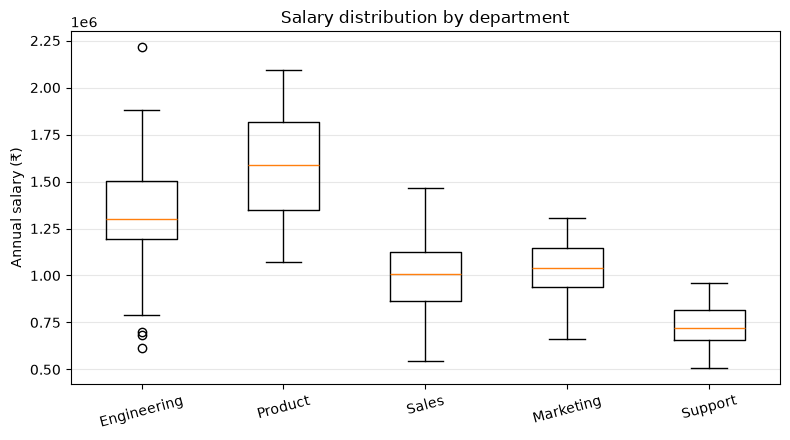

In [41]:
rng = np.random.default_rng(3)

dept_salaries = {
    "Engineering": rng.normal(1_350_000, 260_000, 73),
    "Product": rng.normal(1_590_000, 300_000, 26),
    "Sales": rng.normal(980_000, 190_000, 50),
    "Marketing": rng.normal(1_020_000, 170_000, 23),
    "Support": rng.normal(700_000, 120_000, 34),
}

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.boxplot(list(dept_salaries.values()), tick_labels=list(dept_salaries))

ax.set_ylabel("Annual salary (₹)")
ax.set_title("Salary distribution by department")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

Reading a box plot:

```text
        ┬     ← upper whisker: the largest value within 1.5 × IQR of the box
        │
     ┌──┴──┐  ← top of box: 75th percentile (Q3)
     │     │
     ├─────┤  ← the line inside the box: the MEDIAN (not the mean)
     │     │
     └──┬──┘  ← bottom of box: 25th percentile (Q1)
        │
        ┴     ← lower whisker

        ○     ← individual points beyond the whiskers, flagged as outliers
```

The box holds the middle 50% of the data — its height is the interquartile range (IQR). That makes
the box a direct picture of "how spread out is the typical case", which is exactly what a mean and
standard deviation fail to convey when the data is skewed.

In recent Matplotlib the argument for the labels is `tick_labels`. Older code uses `labels=`, which
still works in many versions but is deprecated — if you hit a warning, that is the rename.

A box plot hides one thing that matters: how many observations each box represents. Support with 34
employees and Product with 26 get equally confident-looking boxes. Two fixes, both worth knowing:

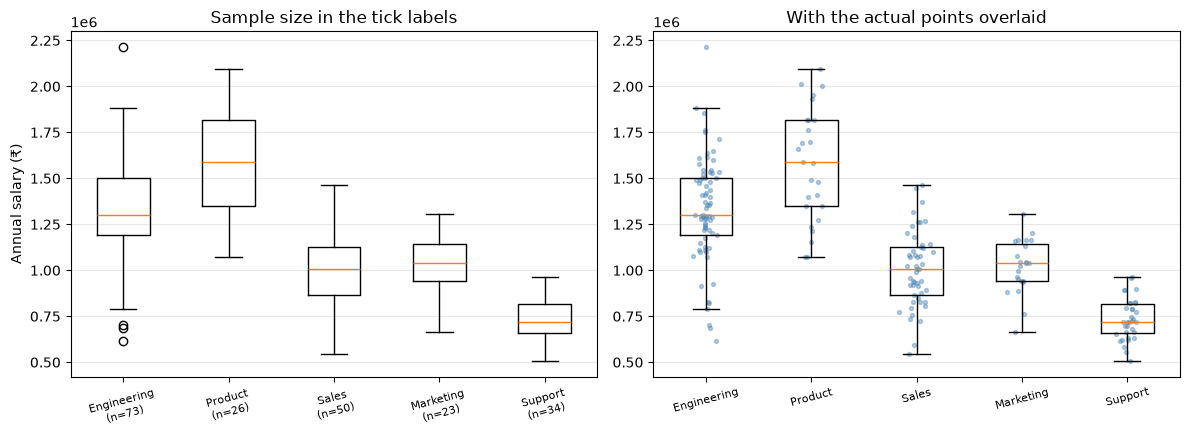

In [42]:
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4.5))

names = list(dept_salaries)
values = list(dept_salaries.values())

left.boxplot(values, tick_labels=[f"{n}\n(n={len(v)})" for n, v in dept_salaries.items()])
left.set_title("Sample size in the tick labels")
left.set_ylabel("Annual salary (₹)")

right.boxplot(values, tick_labels=names, showfliers=False)
for i, series in enumerate(values, start=1):
    jitter = rng.normal(0, 0.055, len(series))
    right.scatter(np.full(len(series), i) + jitter, series, s=8, alpha=0.4, color="steelblue")
right.set_title("With the actual points overlaid")

for ax in (left, right):
    ax.tick_params(axis="x", rotation=15, labelsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

The right-hand version is worth the extra four lines for any chart someone will make a decision
from. Each point is drawn at its group's x position plus a small random horizontal offset — a
**jitter** — so that points at similar salaries do not land on top of each other.
`showfliers=False` turns off the box plot's own outlier markers, since every point is already
drawn and you would otherwise see them twice.

`np.full(len(series), i)` builds an array of the group's x position repeated once per point, and
adding the jitter spreads them out.

### Error bars — showing uncertainty

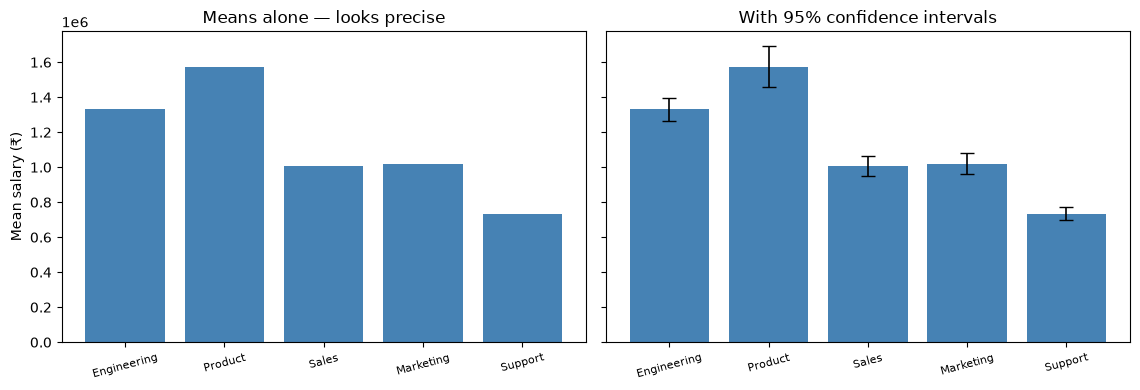

In [43]:
group_means = np.array([v.mean() for v in dept_salaries.values()])
group_sems = np.array([v.std(ddof=1) / np.sqrt(len(v)) for v in dept_salaries.values()])

fig, (bare, with_error) = plt.subplots(1, 2, figsize=(11.5, 4), sharey=True)

bare.bar(names, group_means, color="steelblue")
bare.set_title("Means alone — looks precise")
bare.set_ylabel("Mean salary (₹)")

with_error.bar(names, group_means, yerr=group_sems * 1.96, capsize=5,
               color="steelblue", error_kw=dict(ecolor="black", lw=1.2))
with_error.set_title("With 95% confidence intervals")

for ax in (bare, with_error):
    ax.tick_params(axis="x", rotation=15, labelsize=8)

fig.tight_layout()
plt.show()

`yerr=` adds the bars. We passed 1.96 standard errors, which is roughly a 95% confidence interval
for a mean — the range in which the true average plausibly sits given the sample we have.

The two charts show the same numbers, and only one of them is honest about how much we know.
Marketing's mean rests on 23 people and has a visibly wider interval than Engineering's 73.
A reader looking at the left chart would take the ordering as settled.

The rule: **if the numbers are estimates from samples, show the uncertainty.** And label what the
bars represent — standard deviation, standard error and confidence interval are three different
things and a chart that just says "error bars" is ambiguous.

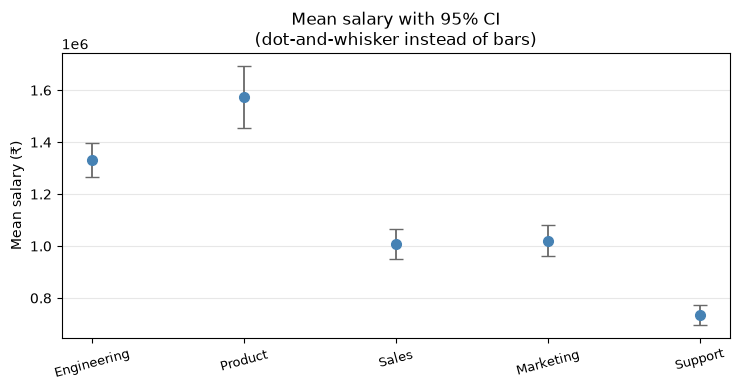

In [44]:
fig, ax = plt.subplots(figsize=(7.5, 4))

ax.errorbar(range(len(names)), group_means, yerr=group_sems * 1.96,
            fmt="o", capsize=5, markersize=7, color="steelblue",
            ecolor="dimgray", elinewidth=1.3)

ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, fontsize=9)
ax.set_ylabel("Mean salary (₹)")
ax.set_title("Mean salary with 95% CI\n(dot-and-whisker instead of bars)")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

`ax.errorbar` with `fmt="o"` draws points instead of bars. For means with uncertainty this is
generally the better chart: the bar's filled area encodes nothing (the quantity is the mean, not
an amount stacked up from zero), and removing it puts the emphasis on the interval.

### Histograms with a reference line

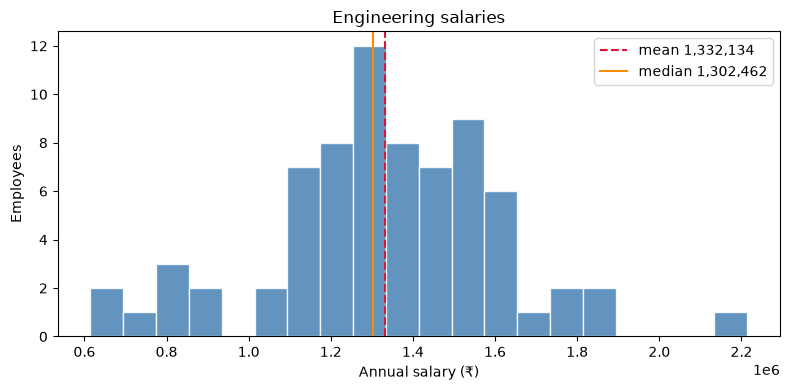

In [45]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(dept_salaries["Engineering"], bins=20, color="steelblue",
        edgecolor="white", alpha=0.85)

mean_val = dept_salaries["Engineering"].mean()
median_val = np.median(dept_salaries["Engineering"])

ax.axvline(mean_val, color="crimson", linestyle="--", linewidth=1.5,
           label=f"mean {mean_val:,.0f}")
ax.axvline(median_val, color="darkorange", linestyle="-", linewidth=1.5,
           label=f"median {median_val:,.0f}")

ax.set_xlabel("Annual salary (₹)")
ax.set_ylabel("Employees")
ax.set_title("Engineering salaries")
ax.legend()

fig.tight_layout()
plt.show()

Drawing the mean and median onto a histogram is a habit worth having. When they sit on top of each
other the distribution is roughly symmetric and the mean is a fair summary; when they separate, the
data is skewed and quoting the mean alone will mislead.

## Plotting from NumPy and Pandas

Matplotlib accepts NumPy arrays everywhere, which you have been relying on already. Pandas goes
one step further and wraps Matplotlib in its own `.plot()` method.

In [46]:
sales = pd.DataFrame({
    "month": pd.date_range("2024-01-01", periods=12, freq="MS"),
    "north": [420, 455, 490, 475, 530, 585, 610, 595, 640, 680, 710, 755],
    "south": [380, 395, 410, 430, 425, 460, 480, 505, 495, 530, 560, 585],
    "east": [210, 225, 240, 255, 280, 295, 310, 305, 330, 345, 370, 390],
}).set_index("month")

sales.head(3)

,north,south,east
month,,,
2024-01-01,420,380,210
2024-02-01,455,395,225
2024-03-01,490,410,240


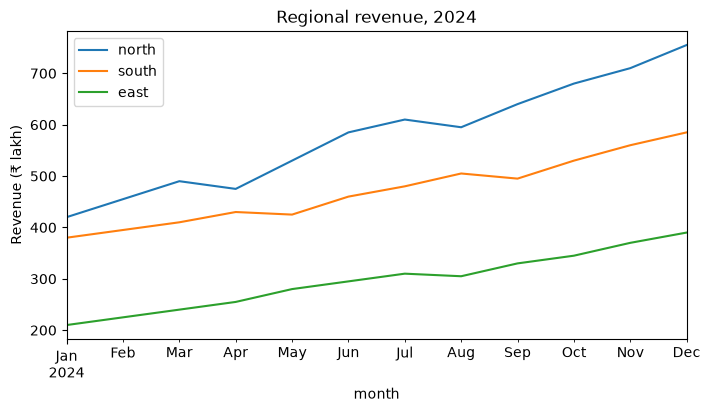

In [47]:
sales.plot(figsize=(8, 4))
plt.ylabel("Revenue (₹ lakh)")
plt.title("Regional revenue, 2024")
plt.show()

One method call, and Pandas has plotted all three columns, labelled them from the column names,
built a legend, and used the index for the x-axis. For exploration this is unbeatable — it is
fewer keystrokes than anything else and it gets the labels right automatically.

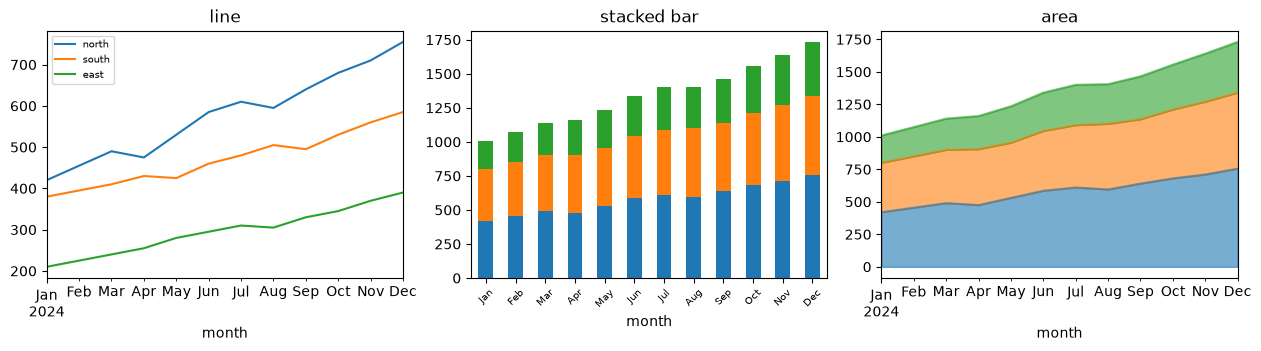

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4), layout="constrained")

sales.plot(ax=axes[0], legend=False, title="line")

# A bar chart treats the index as categories, so give it text labels rather than timestamps.
sales.set_axis(sales.index.strftime("%b")).plot(
    kind="bar", stacked=True, ax=axes[1], title="stacked bar", legend=False)
axes[1].tick_params(axis="x", rotation=45, labelsize=7)

sales.plot(kind="area", ax=axes[2], alpha=0.6, title="area", legend=False)

axes[0].legend(fontsize=7)
plt.show()

The important argument is **`ax=`**. Passing an Axes tells Pandas to draw into your figure instead
of making its own, which is how you combine Pandas' convenience with Matplotlib's control. Without
it, `sales.plot()` creates a new figure and your carefully built subplot grid is ignored.

`kind=` selects the chart type: `"line"` (default), `"bar"`, `"barh"`, `"hist"`, `"box"`,
`"kde"`, `"area"`, `"scatter"`, `"pie"`.

The middle panel needed `set_axis(sales.index.strftime("%b"))`, and the reason is worth knowing
because the error message is unhelpful. Pandas' line and area plots treat a DatetimeIndex as a
continuous time axis; its bar plot treats the index as **discrete categories** and cannot place a
timestamp on a categorical axis. Plotting it directly raises this:

ValueError: Must supply freq for datetime value


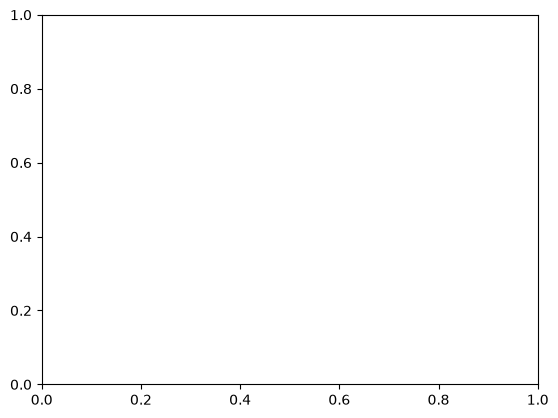

In [49]:
try:
    sales.plot(kind="bar", stacked=True)
    plt.close()
except ValueError as e:
    print("ValueError:", e)

`Must supply freq for datetime value` sounds like it is asking for a resampling frequency, and
what it actually means is "I cannot use dates as bar categories". Converting the index to strings
with `strftime` is the fix. `set_axis` replaces the index without mutating the original, which
keeps `sales` usable as a time series for the other two panels.

### When to use which

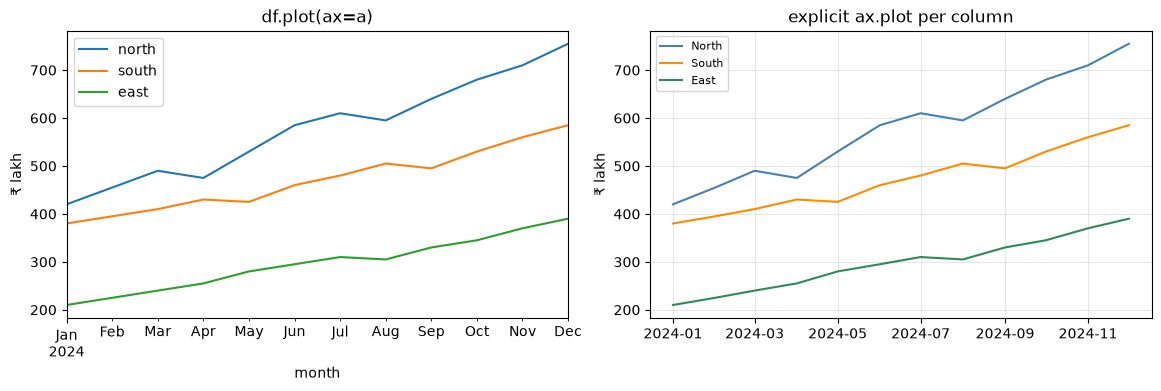

In [50]:
fig, (a, b) = plt.subplots(1, 2, figsize=(11.5, 3.8), layout="constrained")

# Pandas convenience
sales.plot(ax=a, linewidth=1.5)
a.set_title("df.plot(ax=a)")
a.set_ylabel("₹ lakh")

# Explicit Matplotlib, for full control
for column, colour in zip(sales.columns, ["steelblue", "darkorange", "seagreen"]):
    b.plot(sales.index, sales[column], label=column.title(), linewidth=1.5, color=colour)

b.set_title("explicit ax.plot per column")
b.set_ylabel("₹ lakh")
b.legend(fontsize=8)
b.grid(alpha=0.3)

plt.show()

Both are reasonable:

- **`df.plot(ax=...)`** for exploration and for simple charts. It does the labelling for you, and
  the labelling is what people most often get wrong.
- **Explicit `ax.plot` per column** when you need per-series control — a specific colour per
  region, one series highlighted and the rest greyed out, different line styles.

The second gives you the `for` loop, which means the styling can be driven by data. That is the
real dividing line, not sophistication.

### Plotting a grouped summary

The tables built in the Pandas notebook plot directly.

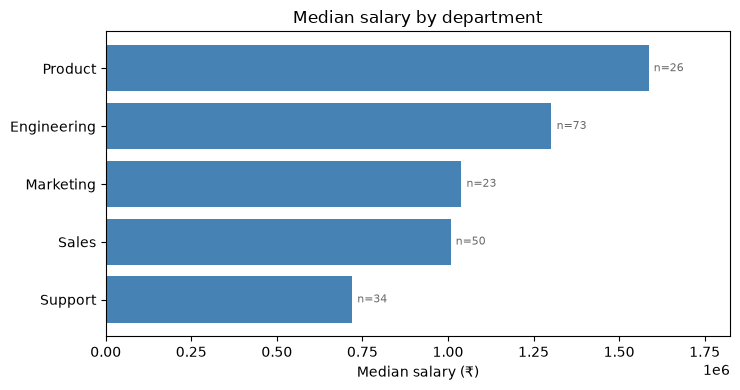

In [51]:
staff_data = pd.DataFrame({
    "department": np.repeat(names, [73, 26, 50, 23, 34]),
    "salary": np.concatenate(list(dept_salaries.values())),
    "experience": np.concatenate([rng.gamma(2.5, 2.6, n) for n in [73, 26, 50, 23, 34]]),
})

summary = (staff_data.groupby("department")
           .agg(median_salary=("salary", "median"), headcount=("salary", "size"))
           .sort_values("median_salary"))

fig, ax = plt.subplots(figsize=(7.5, 4))

bars = ax.barh(summary.index, summary["median_salary"], color="steelblue")

for bar, count in zip(bars, summary["headcount"]):
    ax.text(bar.get_width() + 15_000, bar.get_y() + bar.get_height() / 2,
            f"n={count}", va="center", fontsize=8, color="dimgray")

ax.set_xlabel("Median salary (₹)")
ax.set_title("Median salary by department")
ax.set_xlim(0, summary["median_salary"].max() * 1.15)

fig.tight_layout()
plt.show()

`ax.barh` returns the bar objects, and each one knows its own geometry — `bar.get_width()` is its
length, `bar.get_y()` its vertical position, `bar.get_height()` its thickness. That is how you
place a label at the end of each bar without computing positions yourself.

Labelling bars directly is often better than making the reader trace back to an axis. Matplotlib
also has a purpose-built helper:

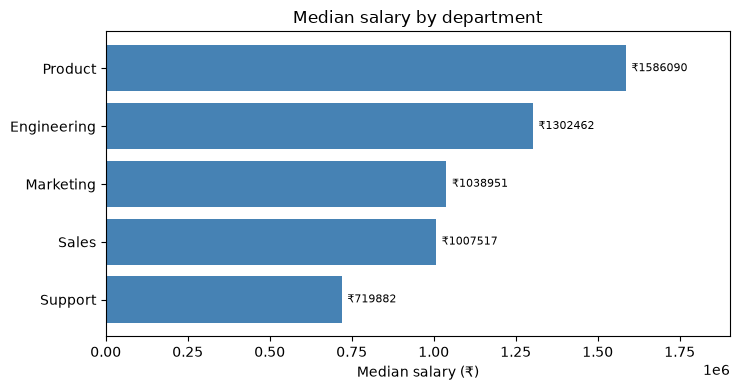

In [52]:
fig, ax = plt.subplots(figsize=(7.5, 4))

bars = ax.barh(summary.index, summary["median_salary"], color="steelblue")
ax.bar_label(bars, fmt="₹%.0f", padding=4, fontsize=8)

ax.set_xlabel("Median salary (₹)")
ax.set_title("Median salary by department")
ax.set_xlim(0, summary["median_salary"].max() * 1.2)

fig.tight_layout()
plt.show()

`ax.bar_label(bars)` labels every bar with its value, and `fmt=` controls the formatting. When the
labels *are* the data, consider whether the chart still earns its place over a small table — but
for a handful of bars, the chart plus labels reads faster than either alone.

## Time series and date axes

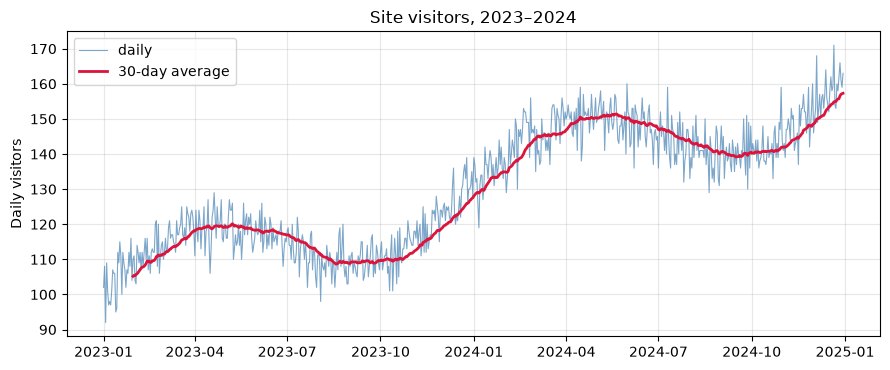

In [53]:
rng_ts = np.random.default_rng(21)
dates = pd.date_range("2023-01-01", periods=730, freq="D")
trend = np.linspace(100, 160, 730)
seasonal = 12 * np.sin(np.arange(730) * 2 * np.pi / 365)
noise = rng_ts.normal(0, 5, 730)

visitors = pd.Series((trend + seasonal + noise).round(0), index=dates, name="visitors")

fig, ax = plt.subplots(figsize=(9, 3.8))

ax.plot(visitors.index, visitors.to_numpy(), linewidth=0.8, color="steelblue", alpha=0.7,
        label="daily")
ax.plot(visitors.index, visitors.rolling(30).mean().to_numpy(), linewidth=2,
        color="crimson", label="30-day average")

ax.set_ylabel("Daily visitors")
ax.set_title("Site visitors, 2023–2024")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

Matplotlib recognises datetime values and formats the axis with sensible date labels by itself.
Notice it chose year and month boundaries rather than printing 730 dates.

The two-line pattern — faint raw data plus a bold rolling average — is the standard way to show a
noisy series. The raw data proves you are not hiding anything; the smoothed line shows the trend.

### Controlling date ticks

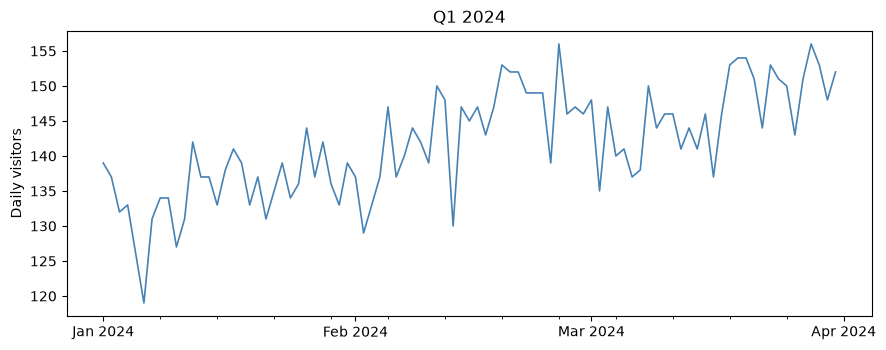

In [54]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(9, 3.6))

quarter = visitors["2024-01-01":"2024-03-31"]
ax.plot(quarter.index, quarter.to_numpy(), linewidth=1.2, color="steelblue")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))

ax.set_ylabel("Daily visitors")
ax.set_title("Q1 2024")

fig.tight_layout()
plt.show()

`matplotlib.dates` gives you **locators** (where the ticks go) and **formatters** (what they say):

- `MonthLocator()`, `YearLocator()`, `DayLocator(interval=7)`, `WeekdayLocator()`
- `DateFormatter("%b %Y")` — the same `strftime` codes as Python's `datetime`: `%Y` four-digit
  year, `%b` short month name, `%d` day, `%H:%M` time.

Minor ticks mark positions without labels, which is a tidy way to show weeks under labelled months.

If date labels overlap, `fig.autofmt_xdate()` rotates and right-aligns them in one call:

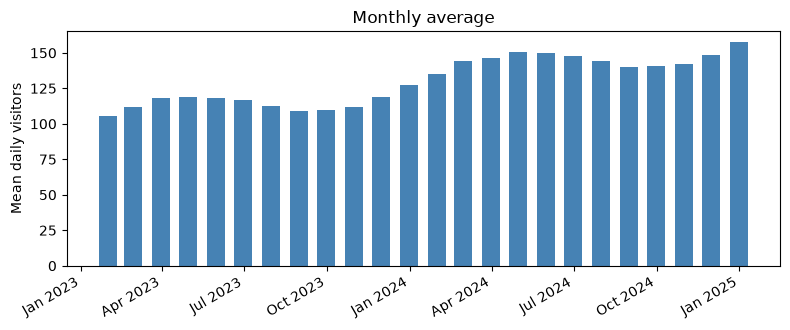

In [55]:
fig, ax = plt.subplots(figsize=(8, 3.4))

monthly = visitors.resample("ME").mean()
ax.bar(monthly.index, monthly.to_numpy(), width=20, color="steelblue")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_ylabel("Mean daily visitors")
ax.set_title("Monthly average")

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

Note `width=20` on the bars. With a date axis, bar width is measured in **days**, not in category
slots, so the default width of 0.8 would produce invisible hairlines. This catches everyone once.

### Filling between lines

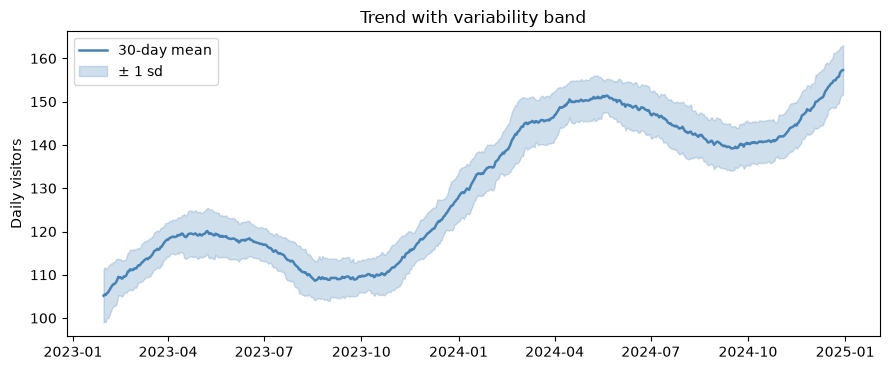

In [56]:
fig, ax = plt.subplots(figsize=(9, 3.8))

smooth = visitors.rolling(30).mean()
std = visitors.rolling(30).std()

ax.plot(visitors.index, smooth.to_numpy(), color="steelblue", linewidth=1.8,
        label="30-day mean")
ax.fill_between(visitors.index,
                (smooth - std).to_numpy(),
                (smooth + std).to_numpy(),
                alpha=0.25, color="steelblue", label="± 1 sd")

ax.set_ylabel("Daily visitors")
ax.set_title("Trend with variability band")
ax.legend()

fig.tight_layout()
plt.show()

`fill_between(x, low, high)` shades the region between two lines. It is the standard way to show a
confidence band, a min–max range, or a forecast interval, and it is far more readable than error
bars on every point of a long series.

`.to_numpy()` appears throughout these date examples. Passing Series directly works in most cases,
but being explicit avoids occasional index-alignment surprises and makes it clear that Matplotlib
only wants the values.

## Saving figures

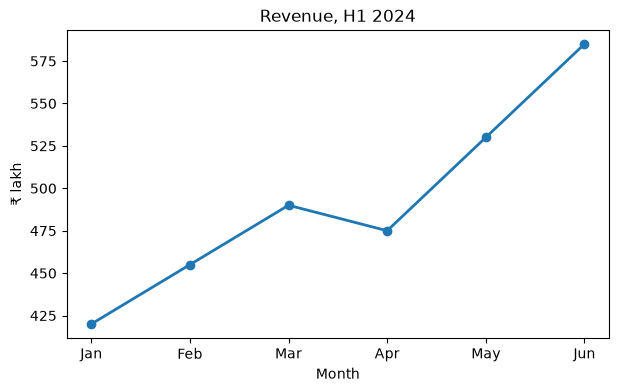

revenue.pdf        12.3 KB
revenue.png        35.5 KB
revenue.svg        23.3 KB


In [57]:
from pathlib import Path

out = Path("matplotlib_output")
out.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(months, revenue, marker="o", linewidth=2)
ax.set_title("Revenue, H1 2024")
ax.set_xlabel("Month")
ax.set_ylabel("₹ lakh")

fig.savefig(out / "revenue.png", dpi=150, bbox_inches="tight")
fig.savefig(out / "revenue.pdf", bbox_inches="tight")
fig.savefig(out / "revenue.svg", bbox_inches="tight")

plt.show()

for f in sorted(out.iterdir()):
    print(f"{f.name:15} {f.stat().st_size / 1024:7.1f} KB")

### Which format

| Format | Use it for | Notes |
| --- | --- | --- |
| **PNG** | slides, web, email, notebooks | Pixels. Set `dpi`. Universally viewable. |
| **PDF** | print, LaTeX documents | Vector — scales to any size without blurring |
| **SVG** | web, further editing | Vector, editable in Inkscape or Illustrator |
| **JPG** | almost never for charts | Lossy compression smears text and thin lines |

The rule: **vector (PDF/SVG) for anything that might be printed or resized, PNG for anything
that will be viewed on a screen at a fixed size, never JPG for a chart.**

### DPI

`dpi` (dots per inch) combines with `figsize` to determine the pixel dimensions:

```text
figsize=(7, 4) at dpi=100  →   700 × 400 pixels
figsize=(7, 4) at dpi=150  →  1050 × 600 pixels
figsize=(7, 4) at dpi=300  →  2100 × 1200 pixels
```

In [58]:
for dpi in [72, 150, 300]:
    path = out / f"dpi_{dpi}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"dpi={dpi:3} → {path.stat().st_size / 1024:6.1f} KB")

dpi= 72 →   15.2 KB
dpi=150 →   35.5 KB


dpi=300 →   79.7 KB


Practical guidance: **100** for a quick look, **150** for slides and documents, **300** for print
or when someone will zoom in. Beyond 300 you are producing large files for no visible gain.

Note that raising the DPI does **not** make the text relatively larger — it makes everything
bigger in pixels. If your labels are too small in a saved figure, increase the font sizes or reduce
`figsize`; do not reach for DPI.

### `bbox_inches="tight"` — the fix for cut-off labels

default crop: 20042 bytes
tight crop  : 22693 bytes


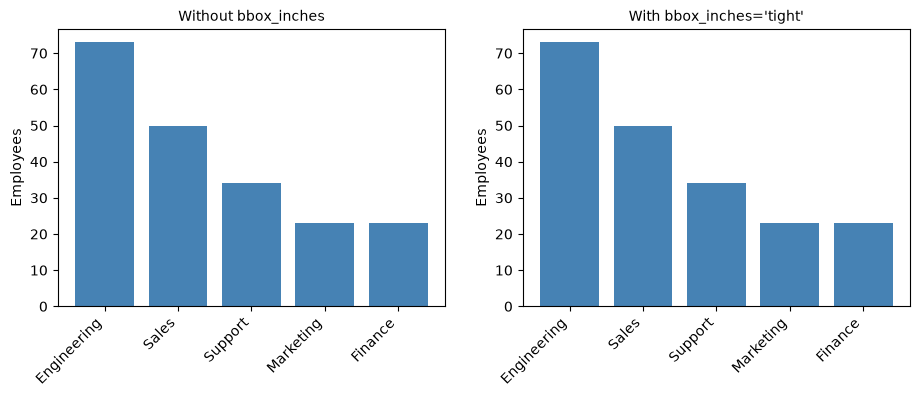

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

for ax, title in zip(axes, ["Without bbox_inches", "With bbox_inches='tight'"]):
    ax.bar(departments, headcount, color="steelblue")
    ax.set_xticks(range(len(departments)))
    ax.set_xticklabels(departments, rotation=45, ha="right")
    ax.set_ylabel("Employees")
    ax.set_title(title, fontsize=10)

fig.savefig(out / "cropped.png", dpi=100)
fig.savefig(out / "tight.png", dpi=100, bbox_inches="tight")

print("default crop:", (out / "cropped.png").stat().st_size, "bytes")
print("tight crop  :", (out / "tight.png").stat().st_size, "bytes")
plt.show()

By default `savefig` writes exactly the figure rectangle, so anything hanging outside it —
long rotated labels, a legend placed outside the axes, a `suptitle` — gets clipped.
`bbox_inches="tight"` expands the saved area to include everything that was drawn.

**Put `bbox_inches="tight"` on every `savefig` call.** There is essentially no downside, and it
prevents the single most common "the chart looked fine in the notebook" problem.

### Other options worth knowing

In [60]:
fig.savefig(out / "transparent.png", dpi=100, bbox_inches="tight", transparent=True)
fig.savefig(out / "padded.png", dpi=100, bbox_inches="tight", pad_inches=0.4)
fig.savefig(out / "white.png", dpi=100, bbox_inches="tight", facecolor="white")

print("written:", sorted(f.name for f in out.iterdir()))

written: ['cropped.png', 'dpi_150.png', 'dpi_300.png', 'dpi_72.png', 'padded.png', 'revenue.pdf', 'revenue.png', 'revenue.svg', 'tight.png', 'transparent.png', 'white.png']


- `transparent=True` — no background, so the chart sits on whatever colour your slide uses.
- `pad_inches` — how much margin `bbox_inches="tight"` leaves.
- `facecolor="white"` — forces a white background, which matters if you use a dark notebook theme,
  because otherwise the saved figure may have a dark background and unreadable text.

### Close figures you are not showing

In [61]:
for i in range(3):
    fig, ax = plt.subplots()
    ax.plot(days, temperature + i)
    fig.savefig(out / f"batch_{i}.png", dpi=80, bbox_inches="tight")
    plt.close(fig)

print("figures still open:", len(plt.get_fignums()))

figures still open: 0


`plt.close(fig)` releases the figure. In a loop writing dozens of files this matters: each open
figure holds memory, and Matplotlib warns after 20 of them.

In a notebook, cells that end with `plt.show()` are cleaned up for you, so you rarely need this
interactively. In a script that generates a report, always close.

In [62]:
import shutil

shutil.rmtree(out)
print("demo output removed")

demo output removed


## Exercises — statistical plots, data sources and saving

**Level 1.** Draw a box plot comparing the salary distributions in `dept_salaries`, with the sample
size shown in each tick label, and save it as a PNG at 150 dpi with nothing cut off.

**Level 2.** Using the `sales` DataFrame, produce a figure with two panels sharing a y-axis: the
three regions as lines on the left, and each region's annual total as a sorted bar chart on the
right. Label the bars with their values.

**Level 3.** Take the `visitors` series. Build a figure showing the daily values faintly, a 30-day
rolling mean boldly, and a shaded band of ± one rolling standard deviation. Then add a second
panel underneath, sharing the x-axis, showing the month-on-month percentage change as bars —
green for positive, red for negative. Explain in a comment why the second panel needs its own
panel rather than a second y-axis on the first.

## Making charts that do not mislead

Every technique in this section is easy to do accidentally. That is the point — misleading charts
are usually made by people with no intention of misleading anyone.

### The truncated bar axis

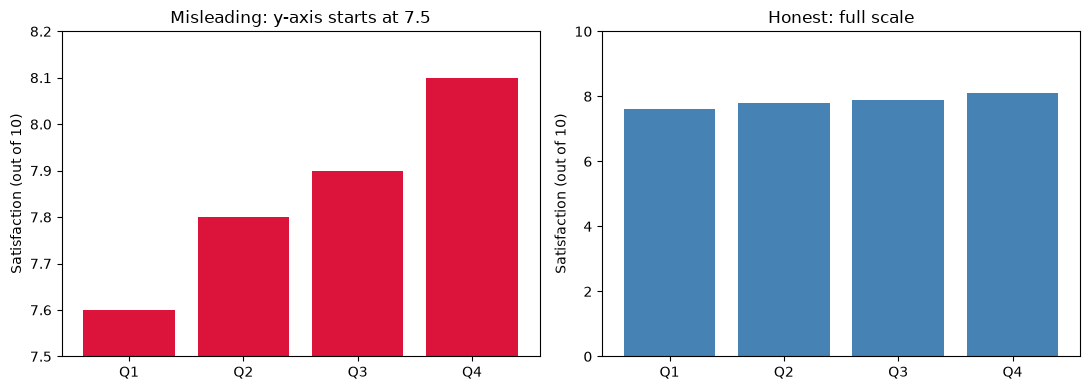

In [63]:
quarters = ["Q1", "Q2", "Q3", "Q4"]
satisfaction = [7.6, 7.8, 7.9, 8.1]

fig, (bad, good) = plt.subplots(1, 2, figsize=(11, 4))

bad.bar(quarters, satisfaction, color="crimson")
bad.set_ylim(7.5, 8.2)
bad.set_title("Misleading: y-axis starts at 7.5")
bad.set_ylabel("Satisfaction (out of 10)")

good.bar(quarters, satisfaction, color="steelblue")
good.set_ylim(0, 10)
good.set_title("Honest: full scale")
good.set_ylabel("Satisfaction (out of 10)")

fig.tight_layout()
plt.show()

Same four numbers. The left chart suggests satisfaction has surged; the right shows a score that
has barely moved, from 7.6 to 8.1.

The left one is not a lie in the sense that the axis is labelled — but people read bar charts by
comparing bar lengths, and a truncated axis makes the lengths meaningless. Q4's bar is roughly six
times the height of Q1's, for a value 7% larger.

**Bar charts must start at zero.** This is the one hard rule in chart design.

If the change is genuinely small and genuinely important, show the change itself rather than
distorting the levels:

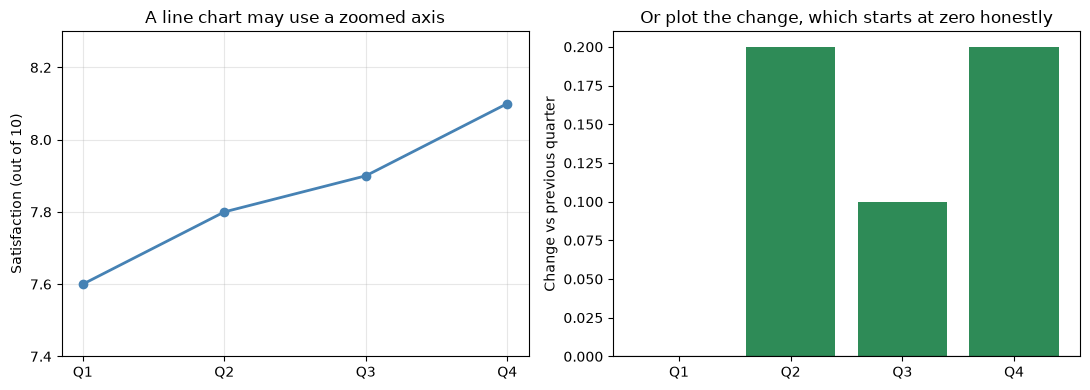

In [64]:
fig, (a, b) = plt.subplots(1, 2, figsize=(11, 4))

a.plot(quarters, satisfaction, marker="o", linewidth=2, color="steelblue")
a.set_ylim(7.4, 8.3)
a.set_ylabel("Satisfaction (out of 10)")
a.set_title("A line chart may use a zoomed axis")
a.grid(alpha=0.3)

change = np.diff(satisfaction, prepend=satisfaction[0])
b.bar(quarters, change, color=["gray"] + ["seagreen"] * 3)
b.axhline(0, color="black", linewidth=0.8)
b.set_ylabel("Change vs previous quarter")
b.set_title("Or plot the change, which starts at zero honestly")

fig.tight_layout()
plt.show()

A **line** chart with a zoomed axis is generally acceptable, because a line encodes position rather
than length and nobody infers a zero baseline from it. Label the axis clearly and you are fine.

The right-hand chart is the better answer when small changes matter: it plots the quarter-on-quarter
difference, where zero is genuinely meaningful and the bars are honest.

### Unequal or reversed axes

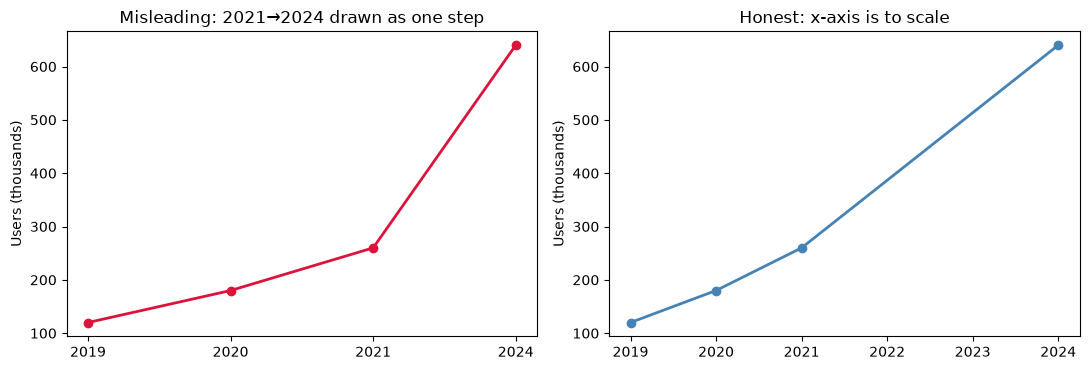

In [65]:
years = np.array([2019, 2020, 2021, 2024])
users = np.array([120, 180, 260, 640])

fig, (bad, good) = plt.subplots(1, 2, figsize=(11, 3.8))

bad.plot(range(len(years)), users, marker="o", linewidth=2, color="crimson")
bad.set_xticks(range(len(years)))
bad.set_xticklabels(years)
bad.set_title("Misleading: 2021→2024 drawn as one step")
bad.set_ylabel("Users (thousands)")

good.plot(years, users, marker="o", linewidth=2, color="steelblue")
good.set_title("Honest: x-axis is to scale")
good.set_ylabel("Users (thousands)")

fig.tight_layout()
plt.show()

The data skips 2022 and 2023. Plotting the values at equal spacing implies steady yearly growth;
plotting them against the actual years shows the three-year gap and a shallower recent slope.

This happens most often when the x values are strings. `plot(["2019", "2020", "2021", "2024"], y)`
treats them as categories and spaces them evenly. If your x-axis is numeric or temporal, keep it
numeric or temporal.

### Too much decoration

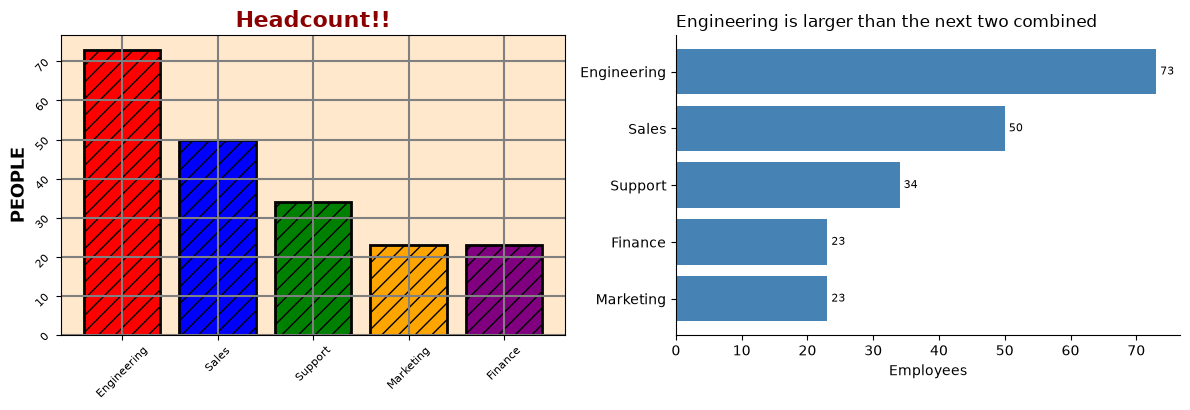

In [66]:
fig, (busy, clean) = plt.subplots(1, 2, figsize=(12, 4.2))

busy.bar(departments, headcount, color=["red", "blue", "green", "orange", "purple"],
         edgecolor="black", linewidth=2, hatch="//")
busy.grid(True, linewidth=1.5, color="gray")
busy.set_title("Headcount!!", fontsize=16, fontweight="bold", color="darkred")
busy.set_ylabel("PEOPLE", fontsize=13, fontweight="bold")
busy.tick_params(labelsize=8, rotation=45)
busy.set_facecolor("#ffe8cc")

order = np.argsort(headcount)
clean.barh(np.array(departments)[order], np.array(headcount)[order], color="steelblue")
clean.set_xlabel("Employees")
clean.set_title("Engineering is larger than the next two combined", loc="left")
clean.spines[["top", "right"]].set_visible(False)
clean.bar_label(clean.containers[0], padding=3, fontsize=8)

fig.tight_layout()
plt.show()

The left chart has five colours encoding nothing, a hatch pattern encoding nothing, a heavy grid
competing with the bars, bold shouting type, and a background tint. None of it adds information.

The right chart removes all of that and adds three things that *do* help: sorted bars, a title
stating the finding, and values labelled directly so the axis is barely needed.

`clean.spines[["top", "right"]].set_visible(False)` removes the top and right border lines. Those
two spines serve no purpose — the data does not extend to them — and dropping them is the single
cheapest way to make a Matplotlib chart look considered rather than default.

### Colour that means nothing versus colour that means something

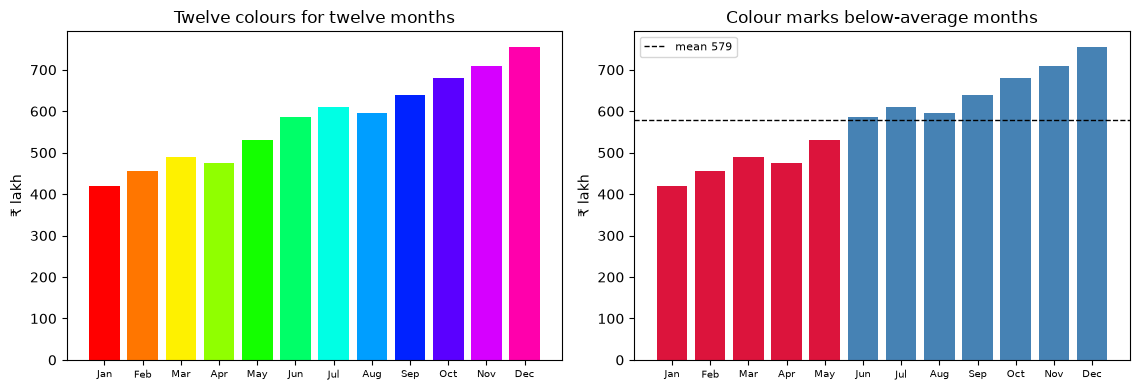

In [67]:
fig, (rainbow, purposeful) = plt.subplots(1, 2, figsize=(11.5, 4))

rainbow.bar(range(12), sales["north"].to_numpy(),
            color=plt.get_cmap("hsv")(np.linspace(0, 0.9, 12)))
rainbow.set_title("Twelve colours for twelve months")
rainbow.set_ylabel("₹ lakh")

values = sales["north"].to_numpy()
colours = ["crimson" if v < values.mean() else "steelblue" for v in values]
purposeful.bar(range(12), values, color=colours)
purposeful.axhline(values.mean(), color="black", linestyle="--", linewidth=1,
                   label=f"mean {values.mean():.0f}")
purposeful.set_title("Colour marks below-average months")
purposeful.set_ylabel("₹ lakh")
purposeful.legend(fontsize=8)

for ax in (rainbow, purposeful):
    ax.set_xticks(range(12))
    ax.set_xticklabels([d.strftime("%b") for d in sales.index], fontsize=7)

fig.tight_layout()
plt.show()

On the left, colour varies with the category, which the x-axis already tells you. It adds visual
noise and invites the reader to look for meaning that is not there.

On the right, colour encodes something the chart could not otherwise show: whether the month was
below average. The list comprehension building `colours` is the whole technique — one colour per
bar, decided by the data.

**Ask what each colour tells the reader.** If the answer is "which category this is, which the
labels already say", use one colour.

### The summary

| Do | Do not |
| --- | --- |
| Start bar axes at zero | Truncate a bar axis to exaggerate differences |
| Sort bars by value | Leave categories in arbitrary order |
| Label axes with units | Assume the reader knows what the numbers are |
| Write a title that states the finding | Title it "Chart of sales data" |
| Use colour to encode information | Use a different colour per category for decoration |
| Share axes across comparable panels | Let each panel pick its own scale |
| Show sample sizes and uncertainty | Present estimates as exact |
| Remove top and right spines, use a faint grid | Add hatching, shadows, 3D effects, heavy grids |

## Common mistakes

### Confusing Figure and Axes methods

AttributeError: 'Axes' object has no attribute 'suptitle'


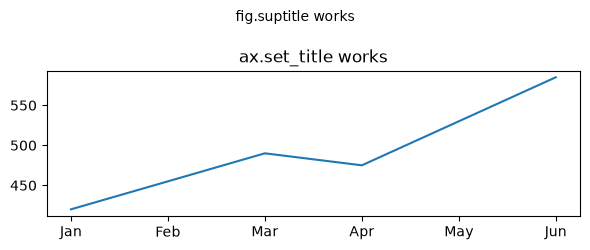

In [68]:
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.plot(months, revenue)

try:
    ax.suptitle("This does not exist on an Axes")
except AttributeError as e:
    print("AttributeError:", e)

ax.set_title("ax.set_title works")
fig.suptitle("fig.suptitle works", fontsize=10)
fig.tight_layout()
plt.show()

Titles exist on both objects and mean different things: `fig.suptitle` is for the whole figure,
`ax.set_title` for one plot. Mixing up which object owns which method is the most common Matplotlib
error, and the fix is always to ask "am I talking about the whole image or one plot?"

Also note that `plt.title()` sets the *Axes* title, not the figure title, despite looking like a
figure-level call. That inconsistency is a consequence of the pyplot interface acting on the
current axes.

### Plots stacking up unexpectedly

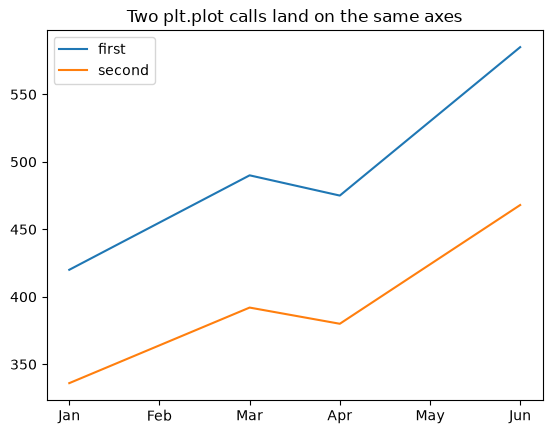

In [69]:
plt.plot(months, revenue, label="first")
plt.plot(months, [r * 0.8 for r in revenue], label="second")
plt.legend()
plt.title("Two plt.plot calls land on the same axes")
plt.show()

Because `plt.plot` draws on the "current" axes, consecutive calls accumulate. That is what you want
for two series on one chart, and a surprise when you meant two separate charts. The cure is to
create each figure explicitly with `plt.subplots()` and draw on the Axes you named.

### Forgetting the legend

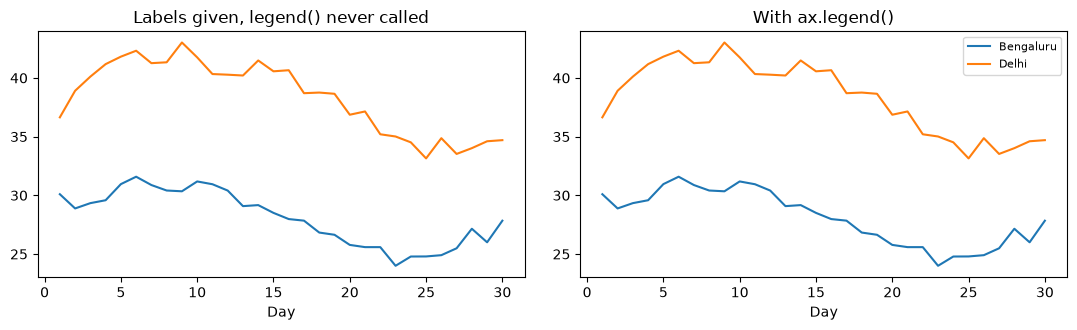

In [70]:
fig, (no_legend, with_legend) = plt.subplots(1, 2, figsize=(11, 3.4))

for ax in (no_legend, with_legend):
    ax.plot(days, bengaluru, label="Bengaluru")
    ax.plot(days, delhi, label="Delhi")
    ax.set_xlabel("Day")

no_legend.set_title("Labels given, legend() never called")
with_legend.set_title("With ax.legend()")
with_legend.legend(fontsize=8)

fig.tight_layout()
plt.show()

`label=` only records the name; `ax.legend()` is what displays it. The left chart has two unlabelled
lines and no way to tell which city is which.

### Overwriting a figure in a loop

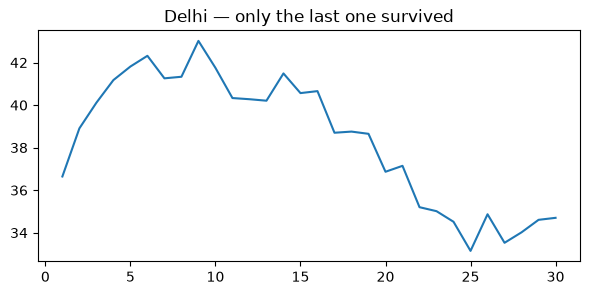

In [71]:
fig, ax = plt.subplots(figsize=(7, 3))

for i, (city, series) in enumerate([("Bengaluru", bengaluru), ("Delhi", delhi)]):
    ax.clear()
    ax.plot(days, series)
    ax.set_title(city)

ax.set_title(ax.get_title() + " — only the last one survived")
plt.show()

`ax.clear()` inside the loop wipes the previous iteration, so only the final city is visible. If you
want one chart per item, create the figure **inside** the loop; if you want them all on one chart,
do not clear.

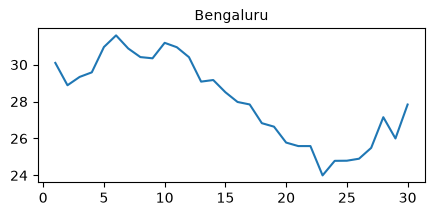

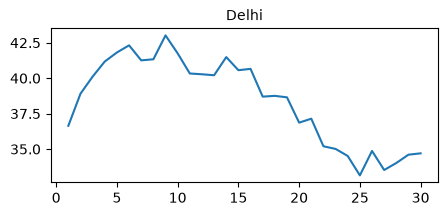

In [72]:
for city, series in [("Bengaluru", bengaluru), ("Delhi", delhi)]:
    fig, ax = plt.subplots(figsize=(5, 2))
    ax.plot(days, series, linewidth=1.5)
    ax.set_title(city, fontsize=10)
    plt.show()

### Labels cut off when saving

Covered in the saving section: `bbox_inches="tight"`. It is listed again here because it is the
mistake people hit most often and the one they are least likely to guess the cause of.

## Debugging: three failures

### Error 1 — mismatched lengths

ValueError: x and y must have same first dimension, but have shapes (10,) and (8,)


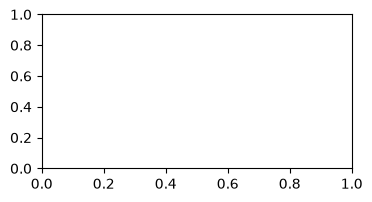

In [73]:
x_values = np.arange(10)
y_values = np.arange(8)

try:
    fig, ax = plt.subplots(figsize=(4, 2))
    ax.plot(x_values, y_values)
    plt.close(fig)
except ValueError as e:
    print("ValueError:", e)

**What Python tells us.** `x and y must have same first dimension, but have shapes (10,) and (8,)`.

**Why it happened.** A line plot needs one y for every x. This usually comes from filtering one
array and not the other, or from an off-by-one in a range.

**Fix.** Print both shapes and find out which one is wrong. Do not "fix" it by trimming the longer
array unless you know that is correct — the mismatch usually means an earlier step went wrong.

x: (10,) y: (8,)


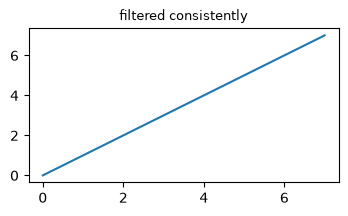

In [74]:
print("x:", x_values.shape, "y:", y_values.shape)

mask = x_values < 8
fig, ax = plt.subplots(figsize=(4, 2))
ax.plot(x_values[mask], y_values)
ax.set_title("filtered consistently", fontsize=9)
plt.show()

### Error 2 — nothing appears at all

This one needs two cells, because the cause is the cell boundary itself. The next cell creates a
figure and stops.

figure created; open figures: [1]


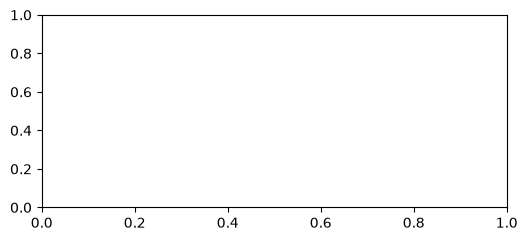

In [75]:
leftover_fig, leftover_ax = plt.subplots(figsize=(6, 2.5))
print("figure created; open figures:", plt.get_fignums())

In [76]:
leftover_ax.plot(months, revenue)
leftover_ax.set_title("Drawn in the next cell")
plt.show()
print("open figures now:", plt.get_fignums())

open figures now: []


**What Python tells us.** Nothing. No error, no chart, and `plt.get_fignums()` reports that there
are no open figures.

**Why it happened.** Jupyter's inline backend displays every figure at the end of the cell that
created it, and then **closes** it. By the time the second cell runs, `leftover_ax` refers to an
Axes on a figure that no longer exists, so the drawing goes nowhere.

**Fix.** Keep the whole figure in one cell — create it, draw on it, and show it together. This is
not a limitation to work around; it is what makes each notebook cell reproducible on its own.

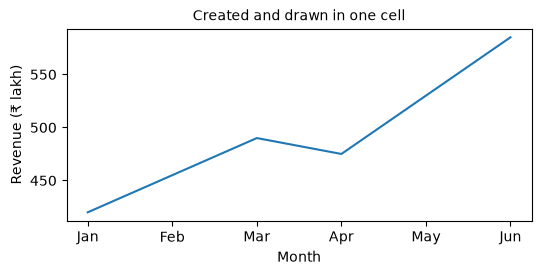

In [77]:
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.plot(months, revenue)
ax.set_title("Created and drawn in one cell", fontsize=10)
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (₹ lakh)")
plt.show()

A related silent failure, worth recognising because the cause looks nothing like the symptom:

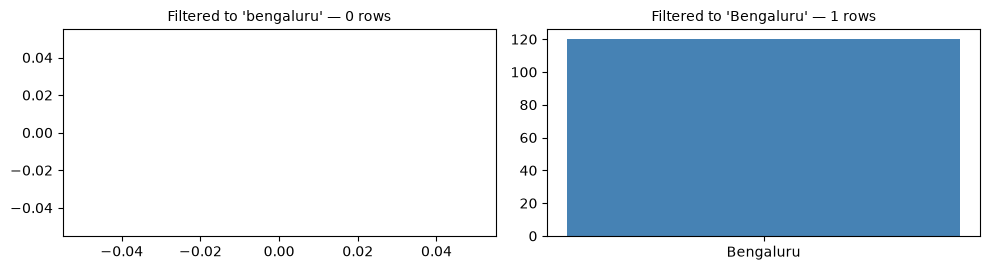

In [78]:
city_data = pd.DataFrame({"city": ["Bengaluru", "Pune", "Mumbai"], "sales": [120, 90, 105]})

fig, (empty, fine) = plt.subplots(1, 2, figsize=(10, 2.8))

wrong_case = city_data[city_data["city"] == "bengaluru"]
empty.bar(wrong_case["city"], wrong_case["sales"], color="steelblue")
empty.set_title(f"Filtered to 'bengaluru' — {len(wrong_case)} rows", fontsize=10)

right_case = city_data[city_data["city"] == "Bengaluru"]
fine.bar(right_case["city"], right_case["sales"], color="steelblue")
fine.set_title(f"Filtered to 'Bengaluru' — {len(right_case)} rows", fontsize=10)

fig.tight_layout()
plt.show()

A filter that matches nothing gives you an empty DataFrame, and plotting an empty DataFrame gives
you empty axes with no complaint. When a chart comes out blank, check `len(data)` before you check
anything about Matplotlib.

### Error 3 — dates plotted as strings

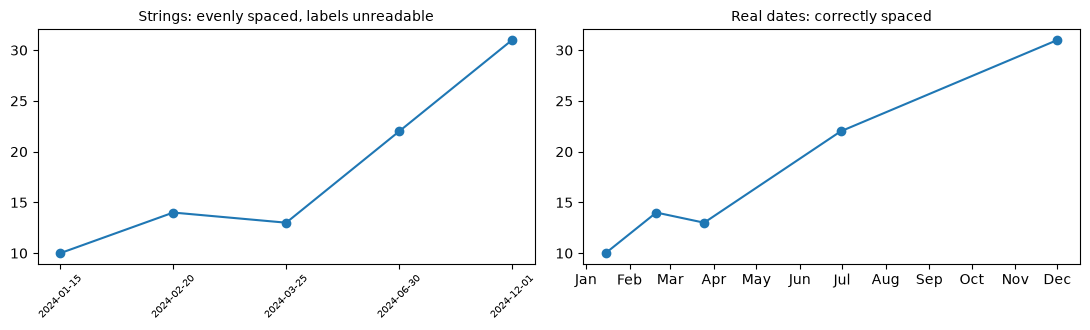

In [79]:
date_strings = ["2024-01-15", "2024-02-20", "2024-03-25", "2024-06-30", "2024-12-01"]
values = [10, 14, 13, 22, 31]

fig, (as_text, as_dates) = plt.subplots(1, 2, figsize=(11, 3.4))

as_text.plot(date_strings, values, marker="o")
as_text.set_title("Strings: evenly spaced, labels unreadable", fontsize=10)
as_text.tick_params(axis="x", labelsize=7, rotation=45)

real_dates = pd.to_datetime(date_strings)
as_dates.plot(real_dates, values, marker="o")
as_dates.set_title("Real dates: correctly spaced", fontsize=10)
as_dates.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

fig.tight_layout()
plt.show()

**What Python tells us.** Nothing again. The chart draws.

**Why it happened.** Matplotlib treated the strings as categories, so January to February (5 weeks)
got the same horizontal distance as June to December (5 months). The apparent trend is wrong.

**Fix.** `pd.to_datetime` before plotting. If your x-axis represents time, it must be datetime —
this is the most common silently-wrong chart there is.

## Mini project — a regional sales dashboard

One figure, several panels, each chosen to answer a specific question. This is where the individual
techniques come together, and where the discipline of "what question does this panel answer" pays
off.

### The data

In [80]:
rng_dash = np.random.default_rng(2024)

n_days = 365
dates = pd.date_range("2024-01-01", periods=n_days, freq="D")
regions = ["North", "South", "East", "West"]
categories = ["Electronics", "Apparel", "Home", "Books"]

records = []
region_scale = {"North": 1.35, "South": 1.0, "East": 0.7, "West": 0.9}
category_scale = {"Electronics": 2.4, "Apparel": 1.2, "Home": 1.0, "Books": 0.45}

for i, date in enumerate(dates):
    weekday_factor = 1.25 if date.dayofweek >= 5 else 1.0
    festive = 1.8 if date.month in (10, 11) else 1.0
    trend = 1 + i / n_days * 0.35

    for region in regions:
        for category in categories:
            base = 18_000 * region_scale[region] * category_scale[category]
            amount = base * weekday_factor * festive * trend * rng_dash.normal(1, 0.22)
            records.append({
                "date": date,
                "region": region,
                "category": category,
                "revenue": round(max(amount, 0.0), 0),
                "units": max(int(amount / rng_dash.uniform(400, 2500)), 0),
            })

orders = pd.DataFrame(records)
print("shape:", orders.shape)
orders.head()

shape: (5840, 5)


,date,region,category,revenue,units
0,2024-01-01,North,Electronics,71521.0,84
1,2024-01-01,North,Apparel,36516.0,17
2,2024-01-01,North,Home,16854.0,24
3,2024-01-01,North,Books,13007.0,16
4,2024-01-01,South,Electronics,60405.0,79


The generator builds in four real effects: regions differ in size, categories differ in price,
weekends are busier, and October–November has a festive spike on top of a gentle upward trend.
An analysis that fails to recover those is an analysis with a bug.

In [81]:
print("total revenue: ₹%.2f crore" % (orders["revenue"].sum() / 10_000_000))
print("date range   :", orders["date"].min().date(), "to", orders["date"].max().date())
print("\nrevenue by region (₹ crore):")
print((orders.groupby("region")["revenue"].sum() / 10_000_000).round(2).to_string())

total revenue: ₹18.90 crore
date range   : 2024-01-01 to 2024-12-30

revenue by region (₹ crore):
region
East     3.36
North    6.48
South    4.72
West     4.34


### Preparing the aggregates

Build every table first, then plot. Mixing aggregation and drawing in the same block makes both
harder to check.

In [82]:
daily = orders.groupby("date")["revenue"].sum()
monthly_by_region = (orders.assign(month=orders["date"].dt.to_period("M").dt.to_timestamp())
                     .pivot_table(index="month", columns="region",
                                  values="revenue", aggfunc="sum"))
by_category = orders.groupby("category")["revenue"].sum().sort_values()
by_weekday = (orders.assign(weekday=orders["date"].dt.day_name())
              .groupby("weekday")["revenue"].mean()
              .reindex(["Monday", "Tuesday", "Wednesday", "Thursday",
                        "Friday", "Saturday", "Sunday"]))
region_category = orders.pivot_table(index="region", columns="category",
                                     values="revenue", aggfunc="sum")
order_sizes = orders["revenue"]

print("daily            :", daily.shape)
print("monthly_by_region:", monthly_by_region.shape)
print("by_category      :", by_category.shape)
print("by_weekday       :", by_weekday.shape)
print("region_category  :", region_category.shape)

daily            : (365,)
monthly_by_region: (12, 4)
by_category      : (4,)
by_weekday       : (7,)
region_category  : (4, 4)


`orders["date"].dt.to_period("M").dt.to_timestamp()` converts each date to the first day of its
month, which is the standard way to build a monthly grouping key while keeping it a real timestamp
so the plot's date axis still works.

`reindex([...])` on `by_weekday` forces the days into calendar order. Without it, grouping would
sort them alphabetically — Friday, Monday, Saturday — which is the kind of detail that makes a
chart look careless.

### Panel 1 — the trend

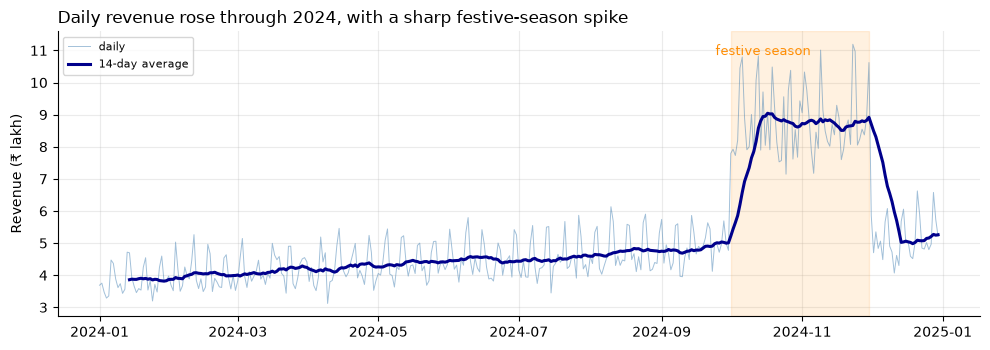

In [83]:
fig, ax = plt.subplots(figsize=(10, 3.6))

ax.plot(daily.index, daily.to_numpy() / 100_000, linewidth=0.7,
        color="steelblue", alpha=0.5, label="daily")
ax.plot(daily.index, daily.rolling(14).mean().to_numpy() / 100_000, linewidth=2.2,
        color="darkblue", label="14-day average")

ax.axvspan(pd.Timestamp("2024-10-01"), pd.Timestamp("2024-11-30"),
           color="darkorange", alpha=0.12)
ax.text(pd.Timestamp("2024-10-15"), daily.max() / 100_000 * 0.97,
        "festive season", color="darkorange", fontsize=9, ha="center")

ax.set_ylabel("Revenue (₹ lakh)")
ax.set_title("Daily revenue rose through 2024, with a sharp festive-season spike", loc="left")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.25)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

`ax.axvspan(start, end)` shades a vertical band, which is how you mark a period on a time series.
At `alpha=0.12` it reads as context rather than as data.

The chart recovered both built-in effects: the upward trend and the October–November spike.

### Panel 2 — composition over time

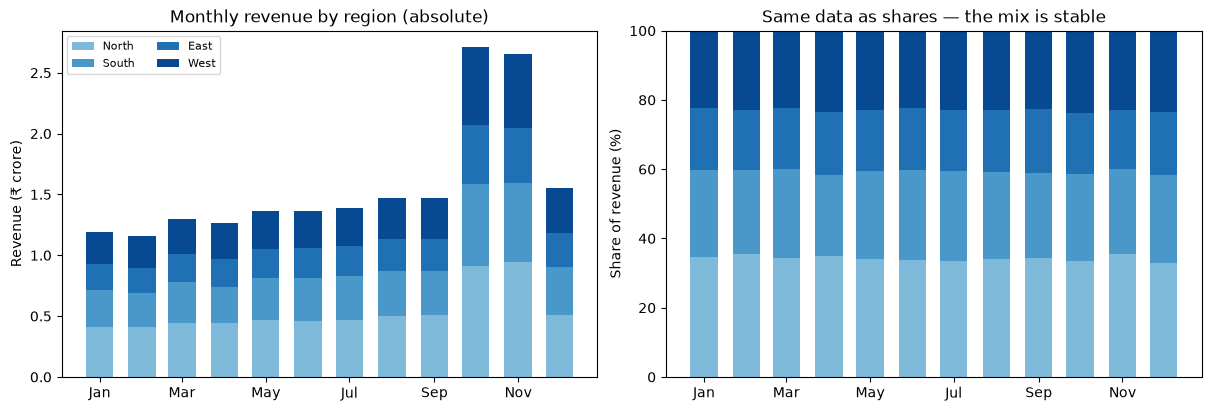

In [84]:
fig, (stacked, share) = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")

x = monthly_by_region.index
bottom = np.zeros(len(x))
colours = plt.get_cmap("Blues")(np.linspace(0.45, 0.9, len(regions)))

for region, colour in zip(regions, colours):
    values = monthly_by_region[region].to_numpy() / 10_000_000
    stacked.bar(x, values, bottom=bottom, width=20, label=region, color=colour)
    bottom += values

stacked.set_ylabel("Revenue (₹ crore)")
stacked.set_title("Monthly revenue by region (absolute)")
stacked.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
stacked.legend(fontsize=8, ncol=2)

proportions = monthly_by_region.div(monthly_by_region.sum(axis=1), axis=0)
bottom = np.zeros(len(x))
for region, colour in zip(regions, colours):
    values = proportions[region].to_numpy() * 100
    share.bar(x, values, bottom=bottom, width=20, label=region, color=colour)
    bottom += values

share.set_ylabel("Share of revenue (%)")
share.set_ylim(0, 100)
share.set_title("Same data as shares — the mix is stable")
share.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.show()

Two views of one table, answering two different questions.

The absolute chart answers "how much did we sell" and shows the festive spike. The share chart
answers "did the regional mix change" and shows that it did not — everything grew together. Had
one region driven the spike alone, its band would have bulged in October.

The stacking is done manually with a running `bottom` array, which is the general pattern:
each series starts where the sum of the previous ones ended.

`monthly_by_region.div(monthly_by_region.sum(axis=1), axis=0)` divides each row by its own total.
The `axis=0` says "align the divisor with the rows", which is the Pandas equivalent of the
`keepdims` broadcasting from the NumPy notebook.

### Panel 3 — the full dashboard

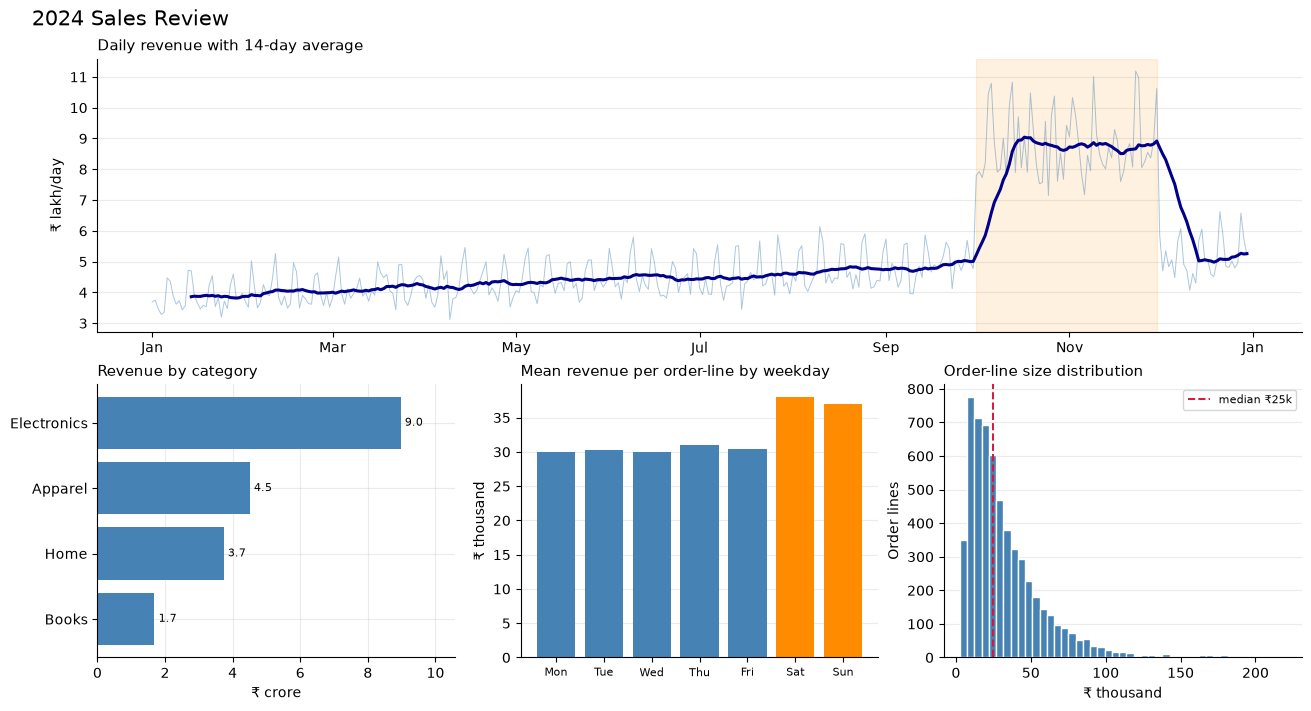

In [85]:
fig, axd = plt.subplot_mosaic(
    [["trend", "trend", "trend"],
     ["category", "weekday", "distribution"]],
    figsize=(13, 7), layout="constrained",
)

# --- trend ---
ax = axd["trend"]
ax.plot(daily.index, daily.to_numpy() / 100_000, linewidth=0.7, color="steelblue", alpha=0.45)
ax.plot(daily.index, daily.rolling(14).mean().to_numpy() / 100_000,
        linewidth=2.2, color="darkblue")
ax.axvspan(pd.Timestamp("2024-10-01"), pd.Timestamp("2024-11-30"),
           color="darkorange", alpha=0.12)
ax.set_ylabel("₹ lakh/day")
ax.set_title("Daily revenue with 14-day average", loc="left", fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# --- category ---
ax = axd["category"]
bars = ax.barh(by_category.index, by_category.to_numpy() / 10_000_000, color="steelblue")
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
ax.set_xlabel("₹ crore")
ax.set_title("Revenue by category", loc="left", fontsize=11)
ax.set_xlim(0, by_category.max() / 10_000_000 * 1.18)

# --- weekday ---
ax = axd["weekday"]
weekday_colours = ["steelblue"] * 5 + ["darkorange"] * 2
ax.bar(range(7), by_weekday.to_numpy() / 1000, color=weekday_colours)
ax.set_xticks(range(7))
ax.set_xticklabels([d[:3] for d in by_weekday.index], fontsize=8)
ax.set_ylabel("₹ thousand")
ax.set_title("Mean revenue per order-line by weekday", loc="left", fontsize=11)

# --- distribution ---
ax = axd["distribution"]
ax.hist(order_sizes / 1000, bins=45, color="steelblue", edgecolor="white")
ax.axvline(order_sizes.median() / 1000, color="crimson", linestyle="--", linewidth=1.4,
           label=f"median ₹{order_sizes.median() / 1000:.0f}k")
ax.set_xlabel("₹ thousand")
ax.set_ylabel("Order lines")
ax.set_title("Order-line size distribution", loc="left", fontsize=11)
ax.legend(fontsize=8)

for ax in axd.values():
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

axd["category"].grid(axis="x", alpha=0.25)

fig.suptitle("2024 Sales Review", fontsize=15, x=0.02, ha="left")
plt.show()

Why each panel is the chart type it is:

- **Trend — line.** The x-axis is time and the spacing is meaningful. A bar chart of 365 days would
  be unreadable and would imply each day is a separate category.
- **Category — sorted horizontal bar.** Four categories, one number each, long labels. Sorted so
  the ranking is immediate, horizontal so "Electronics" fits, labelled so the axis is a formality.
- **Weekday — vertical bar with two colours.** Seven ordered categories, and the colour encodes
  weekend versus weekday, which is the finding rather than decoration.
- **Distribution — histogram.** The question is about the shape of one continuous variable, which
  no summary statistic answers.

The loop at the end applies the same three cosmetic decisions to every panel — faint grid behind
the data, no top and right spines — so the dashboard reads as one design instead of four charts
that happen to be adjacent. That loop is the reason the object-oriented style was worth learning.

### A reusable version

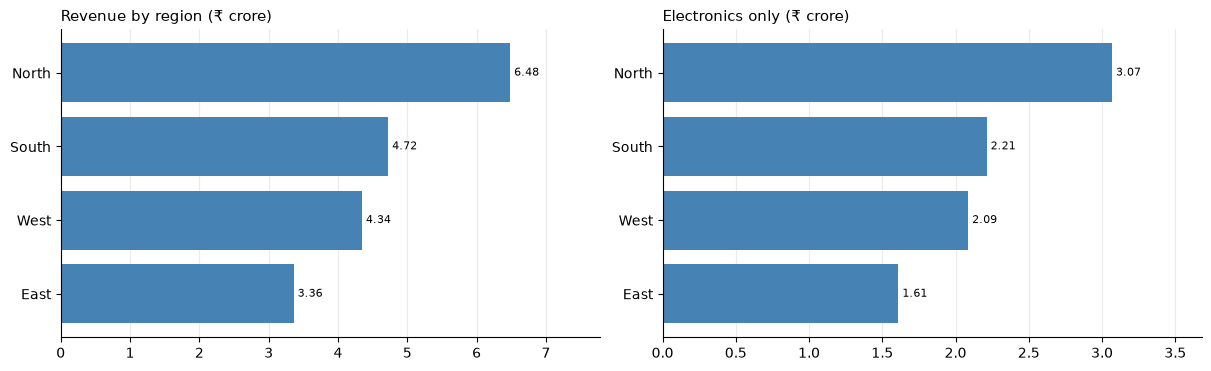

In [86]:
def style_panel(ax, title, ylabel=None, grid_axis="y"):
    """Apply the dashboard's house style to one Axes."""
    ax.set_title(title, loc="left", fontsize=11)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(axis=grid_axis, alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    return ax


def revenue_by_region_chart(ax, orders):
    """Total revenue per region, sorted, in crore."""
    totals = (orders.groupby("region")["revenue"].sum() / 10_000_000).sort_values()
    bars = ax.barh(totals.index, totals.to_numpy(), color="steelblue")
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
    ax.set_xlim(0, totals.max() * 1.2)
    return style_panel(ax, "Revenue by region (₹ crore)", grid_axis="x")


fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), layout="constrained")

revenue_by_region_chart(axes[0], orders)
revenue_by_region_chart(axes[1], orders[orders["category"] == "Electronics"])
axes[1].set_title("Electronics only (₹ crore)", loc="left", fontsize=11)

plt.show()

Two functions, and now the same chart can be drawn for any subset of the data into any Axes. This
is the shape plotting code should take once it is more than a one-off: a function that takes `ax`
and the data, applies the house style, and returns.

Notice what these functions do **not** do: they do not create figures, and they do not call
`plt.show()`. That is what makes them composable — the caller decides the layout.

### What the dashboard says

In [87]:
peak_month = monthly_by_region.sum(axis=1).idxmax()
weekend_lift = (by_weekday[["Saturday", "Sunday"]].mean()
                / by_weekday[["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]].mean() - 1)

print(f"Peak month          : {peak_month:%B %Y}")
print(f"Weekend lift        : {weekend_lift:+.1%}")
print(f"Largest category    : {by_category.idxmax()} "
      f"(₹{by_category.max() / 10_000_000:.2f} crore, "
      f"{by_category.max() / by_category.sum():.0%} of revenue)")
print(f"Largest region      : {orders.groupby('region')['revenue'].sum().idxmax()}")
print(f"Median order line   : ₹{order_sizes.median():,.0f}")

Peak month          : October 2024
Weekend lift        : +23.6%
Largest category    : Electronics (₹8.97 crore, 47% of revenue)
Largest region      : North
Median order line   : ₹24,838


Every one of those figures is visible in the dashboard, which is the test of whether the charts
were the right ones. If a headline number cannot be seen in any panel, either the number does not
matter or a panel is missing.

## Exercises — solutions

### First plots

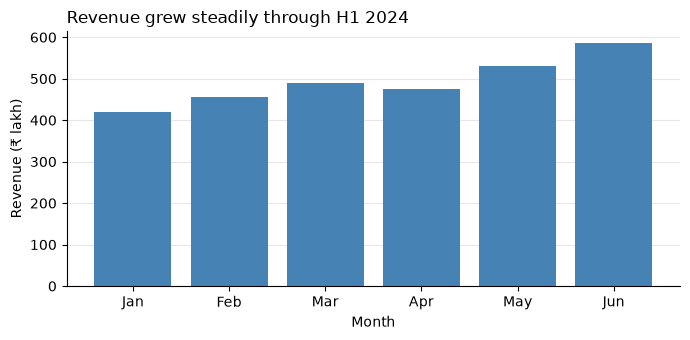

In [88]:
# Level 1
fig, ax = plt.subplots(figsize=(7, 3.5))

ax.bar(months, revenue, color="steelblue")
ax.set_title("Revenue grew steadily through H1 2024", loc="left")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (₹ lakh)")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

The bars start at zero because Matplotlib does that by default for `bar` — worth knowing, and worth
checking whenever you have also set `ylim`.

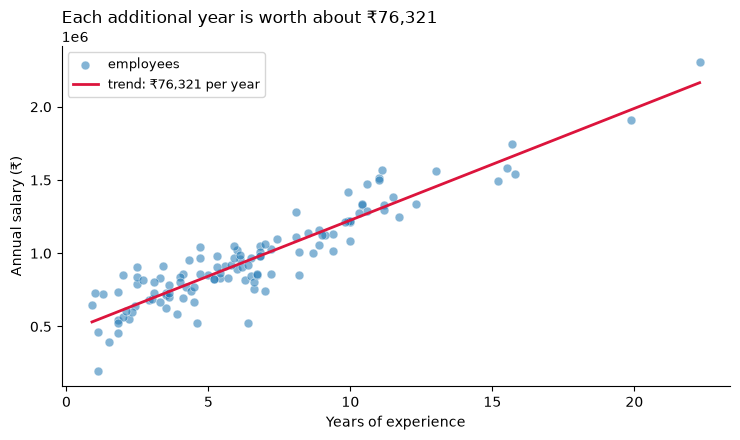

In [89]:
# Level 2
slope, intercept = np.polyfit(experience, salary, 1)
line_x = np.array([experience.min(), experience.max()])
line_y = slope * line_x + intercept

fig, ax = plt.subplots(figsize=(7.5, 4.5))

ax.scatter(experience, salary, alpha=0.55, s=40, edgecolor="white", linewidth=0.5,
           label="employees")
ax.plot(line_x, line_y, color="crimson", linewidth=2,
        label=f"trend: ₹{slope:,.0f} per year")

ax.set_xlabel("Years of experience")
ax.set_ylabel("Annual salary (₹)")
ax.set_title("Each additional year is worth about ₹%s" % f"{slope:,.0f}", loc="left")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

`np.polyfit(x, y, 1)` fits a polynomial of degree 1 — a straight line — and returns
`[slope, intercept]`. Unpacking it into two names makes the next lines readable.

The line is drawn from just two x values, the minimum and maximum, because a straight line needs
only its endpoints. Computing it at all 120 x values would work and would be wasted effort.

Putting the slope in the legend and the title turns the trend line from decoration into a finding:
the chart now says how much a year of experience is worth.

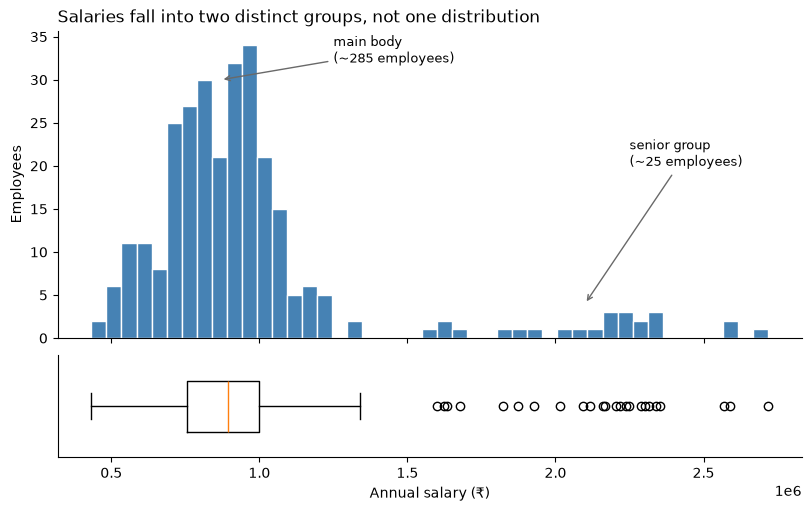

In [90]:
# Level 3
fig, (hist_ax, box_ax) = plt.subplots(2, 1, figsize=(8, 5), sharex=True,
                                      height_ratios=[3, 1], layout="constrained")

hist_ax.hist(salaries, bins=45, color="steelblue", edgecolor="white")
hist_ax.set_ylabel("Employees")
hist_ax.set_title("Salaries fall into two distinct groups, not one distribution", loc="left")
hist_ax.annotate("main body\n(~285 employees)", xy=(870_000, 30), xytext=(1_250_000, 32),
                 arrowprops=dict(arrowstyle="->", color="dimgray"), fontsize=9)
hist_ax.annotate("senior group\n(~25 employees)", xy=(2_100_000, 4), xytext=(2_250_000, 20),
                 arrowprops=dict(arrowstyle="->", color="dimgray"), fontsize=9)

# Matplotlib 3.10 renamed this argument: vert=False became orientation="horizontal".
# Picking the right one keeps the notebook working on either version.
sideways = ({"orientation": "horizontal"}
            if tuple(int(part) for part in matplotlib.__version__.split(".")[:2]) >= (3, 10)
            else {"vert": False})

box_ax.boxplot(salaries, widths=0.5, **sideways)
box_ax.set_yticks([])
box_ax.set_xlabel("Annual salary (₹)")

for ax in (hist_ax, box_ax):
    ax.spines[["top", "right"]].set_visible(False)

plt.show()

Choices made, and why:

- **45 bins.** Enough to separate the two groups clearly; at 10 they merge, at 200 the main body
  breaks into noise.
- **A box plot underneath, sharing the x-axis.** It shows the two groups a *different* way — the
  senior group appears as a run of outlier dots — which makes the point that a single median
  describes this data badly.
- **Annotations with approximate counts.** The reader should not have to estimate group sizes off
  the y-axis.
- **A title that states the finding** rather than naming the variable.

The box plot alone would have been a poor choice here: it would show the outliers but not that they
form a second cluster rather than a scattering of individuals.

The `sideways` dictionary at the top is not part of the lesson about charts — it is a lesson about
libraries. Matplotlib renamed `vert=False` to `orientation="horizontal"` in version 3.10, so the
same call needs different spelling depending on what is installed. Building the keyword arguments
into a dictionary and unpacking it with `**` lets one notebook work on both. You will meet this
pattern any time you write code that has to survive a library upgrade.

### Anatomy and layout

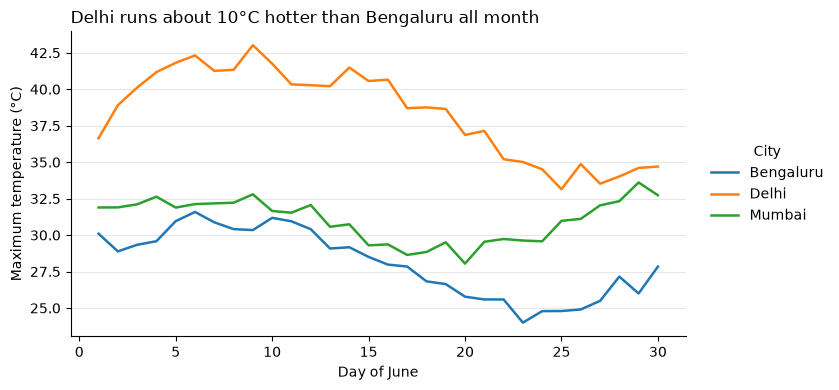

In [91]:
# Level 1
fig, ax = plt.subplots(figsize=(8.5, 4))

for label, series in [("Bengaluru", bengaluru), ("Delhi", delhi), ("Mumbai", mumbai)]:
    ax.plot(days, series, linewidth=1.8, label=label)

ax.set_title("Delhi runs about 10°C hotter than Bengaluru all month", loc="left")
ax.set_xlabel("Day of June")
ax.set_ylabel("Maximum temperature (°C)")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, title="City")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

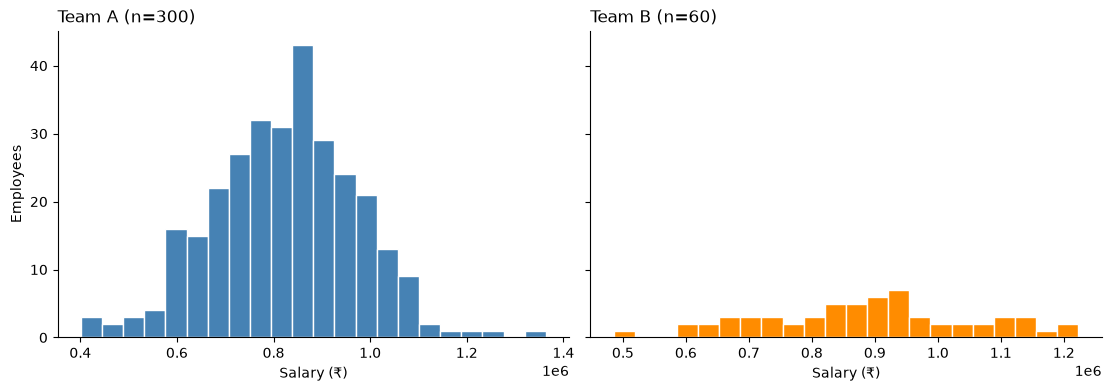

In [92]:
# Level 2
fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True, layout="constrained")

# sharey matters here: both panels show counts of employees, so an unshared y-axis
# would make the 60-person team's bars look as tall as the 300-person team's.
a.hist(group_a, bins=22, color="steelblue", edgecolor="white")
a.set_title("Team A (n=300)", loc="left")
a.set_ylabel("Employees")
a.set_xlabel("Salary (₹)")

b.hist(group_b, bins=22, color="darkorange", edgecolor="white")
b.set_title("Team B (n=60)", loc="left")
b.set_xlabel("Salary (₹)")

for ax in (a, b):
    ax.spines[["top", "right"]].set_visible(False)

plt.show()

`sharey=True` is the right call for these panels, and it makes the smaller team's histogram look
almost flat — which is honest, because it *is* a fifth of the size.

If the question were "do the two teams have the same salary *shape*", shared counts would be the
wrong choice and `density=True` with a shared y-axis would be right. The axis decision follows from
the question, not from a rule.

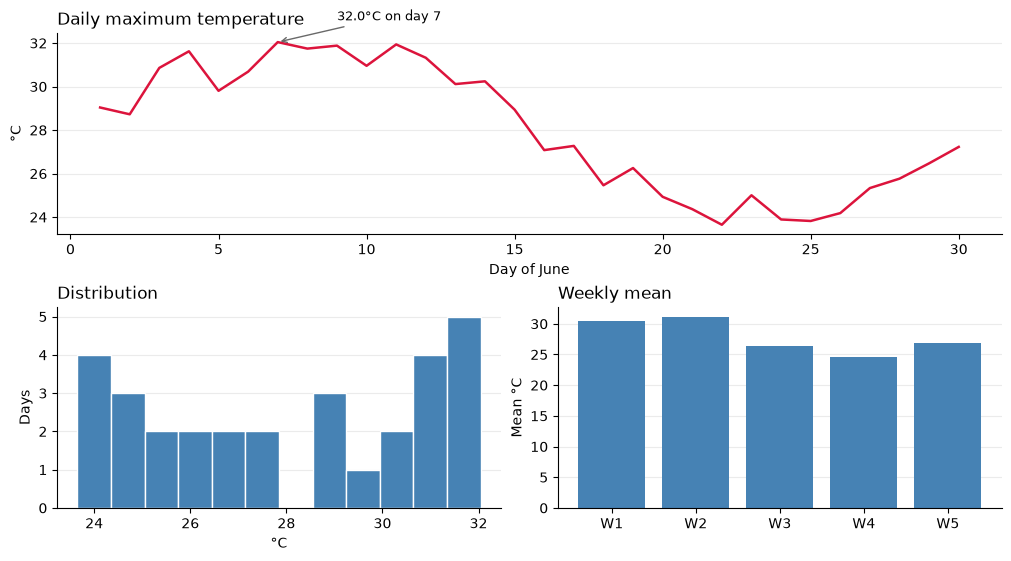

In [93]:
# Level 3
fig, axd = plt.subplot_mosaic(
    [["line", "line"],
     ["hist", "weekly"]],
    figsize=(10, 5.5), layout="constrained",
)

ax = axd["line"]
ax.plot(days, temperature, linewidth=1.8, color="crimson")
peak = temperature.argmax()
ax.annotate(f"{temperature[peak]:.1f}°C on day {days[peak]}",
            xy=(days[peak], temperature[peak]),
            xytext=(days[peak] + 2, temperature[peak] + 1),
            arrowprops=dict(arrowstyle="->", color="dimgray"), fontsize=9)
ax.set_ylabel("°C")
ax.set_xlabel("Day of June")
ax.set_title("Daily maximum temperature", loc="left")

ax = axd["hist"]
ax.hist(temperature, bins=12, color="steelblue", edgecolor="white")
ax.set_xlabel("°C")
ax.set_ylabel("Days")
ax.set_title("Distribution", loc="left")

ax = axd["weekly"]
week = (days - 1) // 7
weekly_means = np.array([temperature[week == w].mean() for w in np.unique(week)])
ax.bar([f"W{w + 1}" for w in np.unique(week)], weekly_means, color="steelblue")
ax.set_ylabel("Mean °C")
ax.set_title("Weekly mean", loc="left")

for ax in axd.values():
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

plt.show()

`(days - 1) // 7` uses integer division to turn day numbers into week numbers: days 1–7 become
week 0, days 8–14 become week 1, and so on. The `- 1` is there because the days start at 1 rather
than 0, and leaving it out would put day 7 in week 1 by itself.

`temperature[week == w]` is boolean masking — select the temperatures whose week number matches —
and the list comprehension does that for each unique week. In Pandas this would be
`df.groupby(week)["temperature"].mean()`, which is shorter; with plain NumPy arrays the
comprehension is the straightforward way.

Note the last week: day 29 and 30 only, so its mean rests on two days. A careful version would
either label that or drop it — a bar that looks like the others but is computed from two
observations is exactly the kind of thing the "show your sample sizes" rule is about.

### Statistical plots, data sources and saving

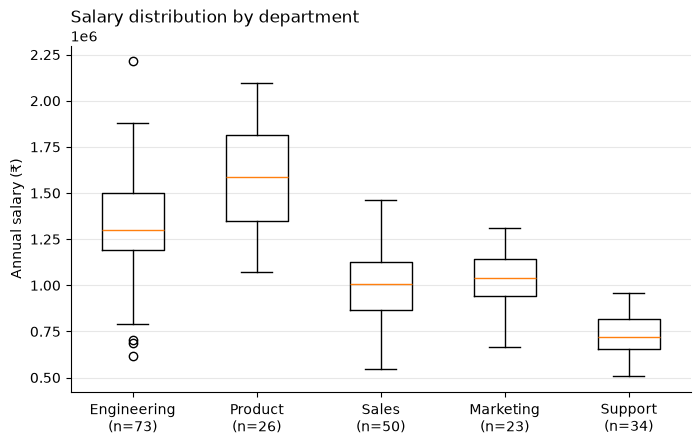

saved: 40 KB


In [94]:
# Level 1
from pathlib import Path

out = Path("exercise_output")
out.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 4.5))

labels = [f"{name}\n(n={len(values)})" for name, values in dept_salaries.items()]

ax.boxplot(list(dept_salaries.values()), tick_labels=labels)
ax.set_ylabel("Annual salary (₹)")
ax.set_title("Salary distribution by department", loc="left")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

fig.savefig(out / "boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

print("saved:", (out / "boxplot.png").stat().st_size // 1024, "KB")

The two-line tick labels come from the `\n` inside the f-string — a newline in a tick label is
allowed, and it is the tidiest way to fit two pieces of information under one box. Putting the
sample size there means a reader cannot accidentally give a 23-person department the same weight
as a 73-person one.

Building the labels into a named variable first, rather than inlining the comprehension in the
`boxplot` call, keeps the call readable. A comprehension as an argument is fine when it is short;
this one is not.

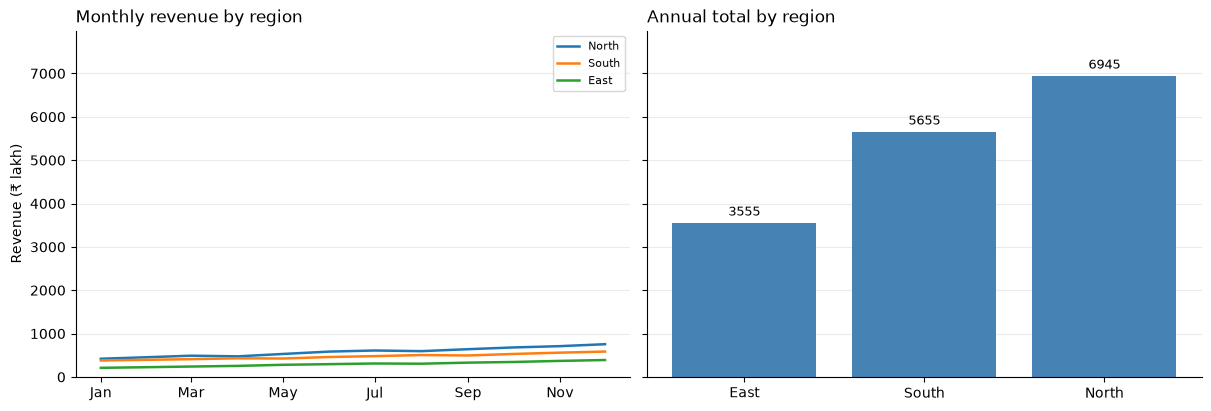

In [95]:
# Level 2
annual = sales.sum().sort_values()

fig, (lines, bars) = plt.subplots(1, 2, figsize=(12, 4), sharey=True, layout="constrained")

for column in sales.columns:
    lines.plot(sales.index, sales[column].to_numpy(), linewidth=1.8, label=column.title())
lines.set_ylabel("Revenue (₹ lakh)")
lines.set_title("Monthly revenue by region", loc="left")
lines.legend(fontsize=8)
lines.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

drawn = bars.bar([name.title() for name in annual.index], annual.to_numpy(), color="steelblue")
bars.bar_label(drawn, fmt="%.0f", padding=3, fontsize=9)
bars.set_title("Annual total by region", loc="left")
bars.set_ylim(0, annual.max() * 1.15)

for ax in (lines, bars):
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

plt.show()

Worth questioning the `sharey=True` that the exercise asked for. The left panel shows monthly
values in the hundreds; the right shows annual totals in the thousands. Forcing them onto one
scale squashes the lines into the bottom of their panel.

So this is a case where sharing the axis is the **wrong** call, and following the instruction
uncritically produced a worse chart. The two panels measure different things — revenue per month
versus revenue per year — and comparable panels is the only reason to share a scale.

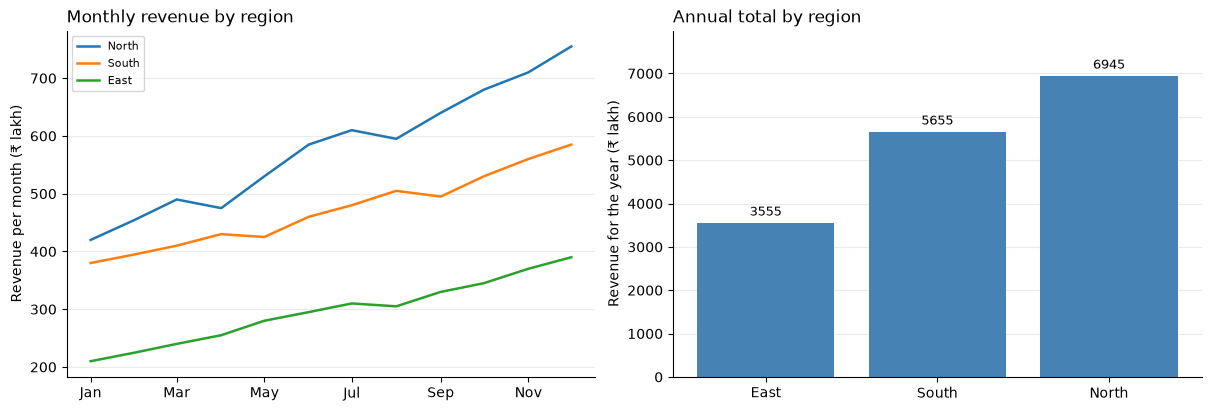

In [96]:
fig, (lines, bars) = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")

for column in sales.columns:
    lines.plot(sales.index, sales[column].to_numpy(), linewidth=1.8, label=column.title())
lines.set_ylabel("Revenue per month (₹ lakh)")
lines.set_title("Monthly revenue by region", loc="left")
lines.legend(fontsize=8)
lines.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

drawn = bars.bar([name.title() for name in annual.index], annual.to_numpy(), color="steelblue")
bars.bar_label(drawn, fmt="%.0f", padding=3, fontsize=9)
bars.set_ylabel("Revenue for the year (₹ lakh)")
bars.set_title("Annual total by region", loc="left")
bars.set_ylim(0, annual.max() * 1.15)

for ax in (lines, bars):
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

plt.show()

Independent axes, each labelled with its own units. Both panels are now readable, and the labels
make clear they are not on the same scale.

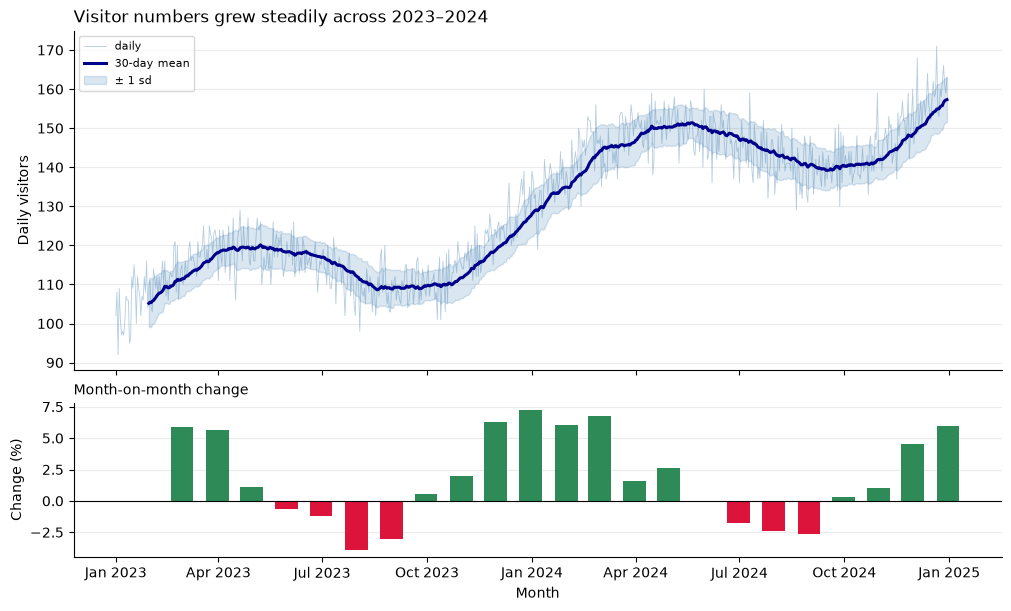

In [97]:
# Level 3
smooth = visitors.rolling(30).mean()
spread = visitors.rolling(30).std()
monthly_change = visitors.resample("ME").mean().pct_change() * 100

fig, (top, bottom) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                  height_ratios=[2.2, 1], layout="constrained")

top.plot(visitors.index, visitors.to_numpy(), linewidth=0.6, color="steelblue", alpha=0.4,
         label="daily")
top.plot(smooth.index, smooth.to_numpy(), linewidth=2.2, color="darkblue", label="30-day mean")
top.fill_between(smooth.index, (smooth - spread).to_numpy(), (smooth + spread).to_numpy(),
                 alpha=0.2, color="steelblue", label="± 1 sd")
top.set_ylabel("Daily visitors")
top.set_title("Visitor numbers grew steadily across 2023–2024", loc="left")
top.legend(fontsize=8, loc="upper left")

# A second panel rather than a second y-axis: percentage change and absolute visitor counts
# share no unit, and two arbitrarily scaled lines in one frame invite the reader to read a
# relationship into wherever they happen to cross.
colours = ["seagreen" if value >= 0 else "crimson" for value in monthly_change.fillna(0)]
bottom.bar(monthly_change.index, monthly_change.fillna(0).to_numpy(), width=20, color=colours)
bottom.axhline(0, color="black", linewidth=0.8)
bottom.set_ylabel("Change (%)")
bottom.set_xlabel("Month")
bottom.set_title("Month-on-month change", loc="left", fontsize=10)
bottom.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

for ax in (top, bottom):
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

plt.show()

The reasoning behind the separate panel, spelled out beyond the comment: a secondary y-axis has no
natural zero alignment with the primary one, so its position is a choice the chart's author makes
and the reader cannot see. Whichever way you scale it, the two lines cross somewhere, and readers
reliably interpret those crossings as meaningful. Two panels sharing an x-axis carry the same
information with none of that suggestion.

`pct_change()` gives `NaN` for the first month, since there is nothing before it. `fillna(0)` keeps
the bar chart from having a gap; drawing no bar at all would be equally defensible, and arguably
more honest.

In [98]:
import shutil

shutil.rmtree(out, ignore_errors=True)
print("exercise output removed")

exercise output removed


## Quick reference

**Starting a figure**

```python
fig, ax = plt.subplots(figsize=(8, 4))
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=True, layout="constrained")
fig, axd = plt.subplot_mosaic([["a", "a"], ["b", "c"]], figsize=(10, 6))
```

**Chart types**

```python
ax.plot(x, y, marker="o", linestyle="--", color="steelblue", linewidth=2, label="A")
ax.scatter(x, y, s=40, alpha=0.6, edgecolor="white")
ax.bar(categories, values)            ax.barh(categories, values)
ax.bar(x - w/2, a, w);  ax.bar(x + w/2, b, w)        # grouped
ax.bar(categories, a);  ax.bar(categories, b, bottom=a)  # stacked
ax.hist(values, bins=30, density=False, edgecolor="white")
ax.boxplot(list_of_arrays, tick_labels=names, showfliers=False)
ax.errorbar(x, y, yerr=err, fmt="o", capsize=5)
ax.fill_between(x, low, high, alpha=0.25)
ax.pie(values, labels=names, autopct="%1.0f%%")
```

**Labels and text**

```python
ax.set_title("What the reader should conclude", loc="left")
ax.set_xlabel("Quantity (units)")     ax.set_ylabel("Quantity (units)")
ax.legend(loc="best", fontsize=9, title="Series")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
ax.annotate("note", xy=(x, y), xytext=(x2, y2), arrowprops=dict(arrowstyle="->"))
ax.text(x, y, "label", fontsize=9, va="center")
ax.bar_label(bars, fmt="%.1f", padding=3)
fig.suptitle("Whole-figure title")
```

**Axes control**

```python
ax.set_xlim(0, 100)                   ax.set_ylim(0, None)
ax.set_xticks([0, 25, 50, 75, 100])   ax.set_xticklabels(names, rotation=45, ha="right")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.grid(axis="y", alpha=0.3);  ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(y, linestyle="--");  ax.axvline(x);  ax.axvspan(x1, x2, alpha=0.1)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{v/1000:.0f}k"))
```

**Dates**

```python
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()
```

**From Pandas**

```python
df.plot(ax=ax)                        df.plot(kind="bar", stacked=True, ax=ax)
series.plot(ax=ax, label="name")      df.plot(kind="scatter", x="a", y="b", ax=ax)
```

**Saving**

```python
fig.savefig("chart.png", dpi=150, bbox_inches="tight")
fig.savefig("chart.pdf", bbox_inches="tight")          # vector, for print
plt.close(fig)                                          # in loops
```

**Layout**

```python
fig.tight_layout()                    # after drawing
plt.subplots(..., layout="constrained")  # or at creation
plt.style.use("seaborn-v0_8-whitegrid")
with plt.style.context("ggplot"): ...
```

### Where to go next

Open `04_BeautifulSoup.ipynb`. So far every dataset has been generated inside a notebook or loaded
from a file. The last notebook collects data from web pages, puts it into a DataFrame, and plots
it — which is the full pipeline these four notebooks have been building towards.